In [1]:
from random import choice
import os
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D
from skimage.feature import peak_local_max
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, bootstrap
from skimage.feature import peak_local_max

from scipy.stats import ttest_ind, mannwhitneyu

Cada dataset final (chile_mayores40_iz, chile_mayores40_der, etc) tiene una distribución de 200 puntos, es decir existen 800 puntos por pais. Por lo tanto hay 400 distancias por pais, 200 distancias para menores de 40 y 200 diastancias para mayores de 40.

In [2]:

chile_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40.xlsx')
chile_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40.xlsx')

chile_menores40_der = chile_menores40[(chile_menores40['Age']=='<40')&(chile_menores40['Politica']=='Right')]
chile_menores40_iz = chile_menores40[(chile_menores40['Age']=='<40')&(chile_menores40['Politica']=='Left')]

chile_mayores40_der= chile_mayores40[(chile_mayores40['Age']=='>40')&(chile_mayores40['Politica']=='Right')]
chile_mayores40_iz= chile_mayores40[(chile_mayores40['Age']=='>40')&(chile_mayores40['Politica']=='Left')]


# Inicializar una lista para almacenar las distancias
distancias_mayor40_Chile = []
distancias_menor40_Chile = []

# Calcular la distancia entre todas las filas
for i in range(len(chile_mayores40_iz)):
    z1_iz_ma = chile_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = chile_mayores40_iz.iloc[i]['z2']
    z1_der_ma = chile_mayores40_der.iloc[i]['z1']
    z2_der_ma = chile_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = chile_menores40_iz.iloc[i]['z1']
    z2_iz_me = chile_menores40_iz.iloc[i]['z2']
    z1_der_me = chile_menores40_der.iloc[i]['z1']
    z2_der_me = chile_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Chile.append(distancia_ma)
    distancias_menor40_Chile.append(distancia_me)
    

In [3]:
# Leer los archivos de Excel para Francia
francia_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40_Francia.xlsx')
francia_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40_Francia.xlsx')

# Filtrar por edad y orientación política para menores de 40
francia_menores40_der = francia_menores40[(francia_menores40['Age']=='<40') & (francia_menores40['Politica']=='Right')]
francia_menores40_iz = francia_menores40[(francia_menores40['Age']=='<40') & (francia_menores40['Politica']=='Left')]

# Filtrar por edad y orientación política para mayores de 40
francia_mayores40_der = francia_mayores40[(francia_mayores40['Age']=='>40') & (francia_mayores40['Politica']=='Right')]
francia_mayores40_iz = francia_mayores40[(francia_mayores40['Age']=='>40') & (francia_mayores40['Politica']=='Left')]

# Inicializar listas para almacenar las distancias
distancias_mayor40_Francia = []
distancias_menor40_Francia = []

# Calcular la distancia entre todas las filas
for i in range(len(francia_mayores40_iz)):
    z1_iz_ma = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma = francia_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me = francia_menores40_iz.iloc[i]['z2']
    z1_der_me = francia_menores40_der.iloc[i]['z1']
    z2_der_me = francia_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Francia.append(distancia_ma)
    distancias_menor40_Francia.append(distancia_me)

In [4]:
# Leer los archivos de Excel para Brasil
brasil_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40_Brasil.xlsx')
brasil_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40_Brasil.xlsx')

# Filtrar por edad y orientación política para menores de 40
brasil_menores40_der = brasil_menores40[(brasil_menores40['Age']=='<40') & (brasil_menores40['Politica']=='Right')]
brasil_menores40_iz = brasil_menores40[(brasil_menores40['Age']=='<40') & (brasil_menores40['Politica']=='Left')]

# Filtrar por edad y orientación política para mayores de 40
brasil_mayores40_der = brasil_mayores40[(brasil_mayores40['Age']=='>40') & (brasil_mayores40['Politica']=='Right')]
brasil_mayores40_iz = brasil_mayores40[(brasil_mayores40['Age']=='>40') & (brasil_mayores40['Politica']=='Left')]

# Inicializar listas para almacenar las distancias
distancias_mayor40_Brasil = []
distancias_menor40_Brasil = []

# Calcular la distancia entre todas las filas
for i in range(len(brasil_mayores40_iz)):
    z1_iz_ma = brasil_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = brasil_mayores40_iz.iloc[i]['z2']
    z1_der_ma = brasil_mayores40_der.iloc[i]['z1']
    z2_der_ma = brasil_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = brasil_menores40_iz.iloc[i]['z1']
    z2_iz_me = brasil_menores40_iz.iloc[i]['z2']
    z1_der_me = brasil_menores40_der.iloc[i]['z1']
    z2_der_me = brasil_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Brasil.append(distancia_ma)
    distancias_menor40_Brasil.append(distancia_me)


### Plot B

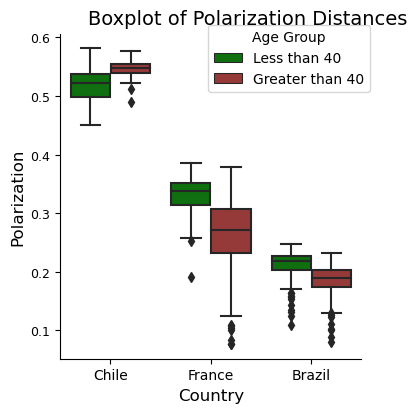

In [5]:
#Crear un DataFrame para facilitar la creación del boxplot
data_b = {
    'Country': (
        ['Chile'] * 200 + ['Chile'] * 200 +
        ['France'] * 200 + ['France'] * 200 +
        ['Brazil'] * 200 + ['Brazil'] * 200 

    ),
    'Age Group': (
        ['Less than 40'] * 200 + ['Greater than 40'] * 200 +
        ['Less than 40'] * 200 + ['Greater than 40'] * 200 +
        ['Less than 40'] * 200 + ['Greater than 40'] * 200
    ),
    'Distance': np.concatenate([
        distancias_menor40_Chile, distancias_mayor40_Chile,
        distancias_menor40_Francia, distancias_mayor40_Francia,
        distancias_menor40_Brasil, distancias_mayor40_Brasil

    ])
}

df_b = pd.DataFrame(data_b)


# Ajustar el estilo de la gráfica con sns.catplot
g = sns.catplot(
    x='Country',          # Eje X
    y='Distance',         # Eje Y
    hue='Age Group',      # Agrupar por Age Group
    data=df_b,
    kind='box',
    palette={'Less than 40': 'green', 'Greater than 40': 'brown'},  # Ejemplo de paleta
    height=4,
    aspect=1
)

# Ajustar etiquetas de ejes y título principal (suptitle)
g.set_axis_labels('Country', 'Polarization', fontsize=12)
plt.suptitle('Boxplot of Polarization Distances', y=1.02, fontsize=14)

# (Opcional) Ajustar el rango del eje Y si lo deseas
# plt.ylim(-0.02, 0.20)

# Ajustar tamaño de las etiquetas en el eje Y
for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=9)

# Eliminar la leyenda por defecto generada por catplot
g._legend.remove()

# Agregar una leyenda personalizada
plt.legend(
    loc='lower right',
    bbox_to_anchor=(1.05, 0.8),
    title='Age Group',
    fontsize=10,
    title_fontsize=10
)

# Mostrar el gráfico
plt.show()


### Plot A

In [6]:
# Leer los archivos de Excel para Francia
francia_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40_Francia.xlsx')
francia_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40_Francia.xlsx')

# Filtrar por edad y orientación política para menores de 40
francia_menores40_der = francia_menores40[(francia_menores40['Age']=='<40') & (francia_menores40['Politica']=='Right')]
francia_menores40_iz = francia_menores40[(francia_menores40['Age']=='<40') & (francia_menores40['Politica']=='Left')]

# Filtrar por edad y orientación política para mayores de 40
francia_mayores40_der = francia_mayores40[(francia_mayores40['Age']=='>40') & (francia_mayores40['Politica']=='Right')]
francia_mayores40_iz = francia_mayores40[(francia_mayores40['Age']=='>40') & (francia_mayores40['Politica']=='Left')]

# Inicializar listas para almacenar las distancias
distancias_mayor40_Francia = []
distancias_menor40_Francia = []

# Calcular la distancia entre todas las filas
for i in range(len(francia_mayores40_iz)):
    z1_iz_ma = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma = francia_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me = francia_menores40_iz.iloc[i]['z2']
    z1_der_me = francia_menores40_der.iloc[i]['z1']
    z2_der_me = francia_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Francia.append(distancia_ma)
    distancias_menor40_Francia.append(distancia_me)


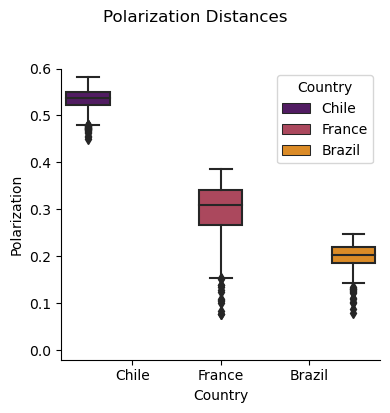

In [7]:
# Crear un DataFrame sin diferenciar por grupo etario
data_a = {
    'Country': (
        ['Chile'] * 400 +
        ['France'] * 400 +
        ['Brazil'] * 400 
    ),
    'Distance': np.concatenate([
        distancias_menor40_Chile, distancias_mayor40_Chile,
        distancias_menor40_Francia, distancias_mayor40_Francia,
        distancias_menor40_Brasil, distancias_mayor40_Brasil
    ])
}

df_a = pd.DataFrame(data_a)

g = sns.catplot(
    x='Country',
    y='Distance',
    hue='Country',
    data=df_a,
    kind='box',
    order=['Chile', 'France', 'Brazil'],  # to keep consistent order
    height=4,          # figure is 4" tall
    aspect=1,          # aspect=1 --> figure is 4" wide (square)
    width=1.5,         # increase box width
    palette='inferno'
)

# Remove catplot's auto-legend
if g._legend is not None:
    g._legend.remove()

# Adjust axis labels/title
g.set_axis_labels('Country', 'Polarization')
plt.suptitle('Polarization Distances', y=1.02)

# Tighten the x-limits to reduce white space at the edges
for ax in g.axes.flat:
    ax.set_ylim(-0.02, 0.60)
    ax.set_xlim(-0.8, 2.8)  # Adjust if needed to avoid cutting boxes

# Re-add the legend in a custom location
plt.legend(loc='upper right', title='Country')

# Use tight_layout to help prevent cutoff
plt.tight_layout()
plt.show()

In [8]:
# Cargar datos de Brasil y Francia
brasil = pd.read_excel('Coordenadas/Coordenadas_peaks_AllUsers_Brasil.xlsx')
francia = pd.read_excel('Coordenadas/Coordenadas_peaks_AllUsers_Francia.xlsx')
chile = pd.read_excel('Coordenadas/Coordenadas_peaks_AllUsers.xlsx')


# Filtrar por política para Brasil
der_brasil = brasil[brasil['Politica'] == 'Right']
iz_brasil = brasil[brasil['Politica'] == 'Left']
iz_chile = chile[chile['Politica']=='Left']

# Filtrar por política para Francia
der_francia = francia[francia['Politica'] == 'Right']
iz_francia = francia[francia['Politica'] == 'Left']
der_chile = chile[chile['Politica']=='Right']


In [9]:
# Inicializar listas para almacenar las distancias
distancias_der_all_ma = []
distancias_iz_all_ma = []
distancias_der_all_me = []
distancias_iz_all_me = []


# Calcular la distancia entre todas las filas
for i in range(len(francia_mayores40_iz)):
    z1_iz_ma = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma = francia_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me = francia_menores40_iz.iloc[i]['z2']
    z1_der_me = francia_menores40_der.iloc[i]['z1']
    z2_der_me = francia_menores40_der.iloc[i]['z2']
    
    z1_iz_all = iz_francia.iloc[i]['z1']
    z2_iz_all = iz_francia.iloc[i]['z2']
    z1_der_all = der_francia.iloc[i]['z1']
    z2_der_all = der_francia.iloc[i]['z2']
    
     # Calcular distancias
    distancia_der_all_ma = np.sqrt((z1_der_all - z1_der_ma) ** 2 + (z2_der_all - z2_der_ma) ** 2)
    distancia_iz_all_ma = np.sqrt((z1_iz_all - z1_iz_ma) ** 2 + (z2_iz_all - z2_iz_ma) ** 2)
    
    distancia_der_all_me = np.sqrt((z1_der_all - z1_der_me) ** 2 + (z2_der_all - z2_der_me) ** 2)
    distancia_iz_all_me = np.sqrt((z1_iz_all - z1_iz_me) ** 2 + (z2_iz_all - z2_iz_me) ** 2)
    
    # Agregar distancias a las listas
    distancias_der_all_ma.append(distancia_der_all_ma)
    distancias_iz_all_ma.append(distancia_iz_all_ma)
    distancias_der_all_me.append(distancia_der_all_me)
    distancias_iz_all_me.append(distancia_iz_all_me)

    

    # Inicializar listas para almacenar las distancias
distancias_der_all_ma_chile = []
distancias_iz_all_ma_chile = []
distancias_der_all_me_chile = []
distancias_iz_all_me_chile = []

distancias_der_all_ma_brasil = []
distancias_iz_all_ma_brasil = []
distancias_der_all_me_brasil = []
distancias_iz_all_me_brasil = []

# Calcular la distancia para Chile (mayores de 40 y menores de 40)
for i in range(len(chile_mayores40_iz)):
    # Coordenadas para Chile (mayores de 40)
    z1_iz_ma_chile = chile_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_chile = chile_mayores40_iz.iloc[i]['z2']
    z1_der_ma_chile = chile_mayores40_der.iloc[i]['z1']
    z2_der_ma_chile = chile_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Chile (menores de 40)
    z1_iz_me_chile = chile_menores40_iz.iloc[i]['z1']
    z2_iz_me_chile = chile_menores40_iz.iloc[i]['z2']
    z1_der_me_chile = chile_menores40_der.iloc[i]['z1']
    z2_der_me_chile = chile_menores40_der.iloc[i]['z2']
    
    # Coordenadas para Chile (all users)
    z1_iz_all_chile = iz_chile.iloc[i]['z1']
    z2_iz_all_chile = iz_chile.iloc[i]['z2']
    z1_der_all_chile = der_chile.iloc[i]['z1']
    z2_der_all_chile = der_chile.iloc[i]['z2']
    
    # Calcular distancias para Chile
    distancia_der_all_ma_chile = np.sqrt((z1_der_all_chile - z1_der_ma_chile) ** 2 + (z2_der_all_chile - z2_der_ma_chile) ** 2)
    distancia_iz_all_ma_chile = np.sqrt((z1_iz_all_chile - z1_iz_ma_chile) ** 2 + (z2_iz_all_chile - z2_iz_ma_chile) ** 2)
    
    distancia_der_all_me_chile = np.sqrt((z1_der_all_chile - z1_der_me_chile) ** 2 + (z2_der_all_chile - z2_der_me_chile) ** 2)
    distancia_iz_all_me_chile = np.sqrt((z1_iz_all_chile - z1_iz_me_chile) ** 2 + (z2_iz_all_chile - z2_iz_me_chile) ** 2)
    
    # Agregar distancias a las listas
    distancias_der_all_ma_chile.append(distancia_der_all_ma_chile)
    distancias_iz_all_ma_chile.append(distancia_iz_all_ma_chile)
    distancias_der_all_me_chile.append(distancia_der_all_me_chile)
    distancias_iz_all_me_chile.append(distancia_iz_all_me_chile)

# Calcular la distancia para Brasil (mayores de 40 y menores de 40)
for i in range(len(brasil_mayores40_iz)):
    # Coordenadas para Brasil (mayores de 40)
    z1_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z2']
    z1_der_ma_brasil = brasil_mayores40_der.iloc[i]['z1']
    z2_der_ma_brasil = brasil_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Brasil (menores de 40)
    z1_iz_me_brasil = brasil_menores40_iz.iloc[i]['z1']
    z2_iz_me_brasil = brasil_menores40_iz.iloc[i]['z2']
    z1_der_me_brasil = brasil_menores40_der.iloc[i]['z1']
    z2_der_me_brasil = brasil_menores40_der.iloc[i]['z2']
    
    # Coordenadas para Brasil (all users)
    z1_iz_all_brasil = iz_brasil.iloc[i]['z1']
    z2_iz_all_brasil = iz_brasil.iloc[i]['z2']
    z1_der_all_brasil = der_brasil.iloc[i]['z1']
    z2_der_all_brasil = der_brasil.iloc[i]['z2']
    
    # Calcular distancias para Brasil
    distancia_der_all_ma_brasil = np.sqrt((z1_der_all_brasil - z1_der_ma_brasil) ** 2 + (z2_der_all_brasil - z2_der_ma_brasil) ** 2)
    distancia_iz_all_ma_brasil = np.sqrt((z1_iz_all_brasil - z1_iz_ma_brasil) ** 2 + (z2_iz_all_brasil - z2_iz_ma_brasil) ** 2)
    
    distancia_der_all_me_brasil = np.sqrt((z1_der_all_brasil - z1_der_me_brasil) ** 2 + (z2_der_all_brasil - z2_der_me_brasil) ** 2)
    distancia_iz_all_me_brasil = np.sqrt((z1_iz_all_brasil - z1_iz_me_brasil) ** 2 + (z2_iz_all_brasil - z2_iz_me_brasil) ** 2)
    
    # Agregar distancias a las listas
    distancias_der_all_ma_brasil.append(distancia_der_all_ma_brasil)
    distancias_iz_all_ma_brasil.append(distancia_iz_all_ma_brasil)
    distancias_der_all_me_brasil.append(distancia_der_all_me_brasil)
    distancias_iz_all_me_brasil.append(distancia_iz_all_me_brasil)



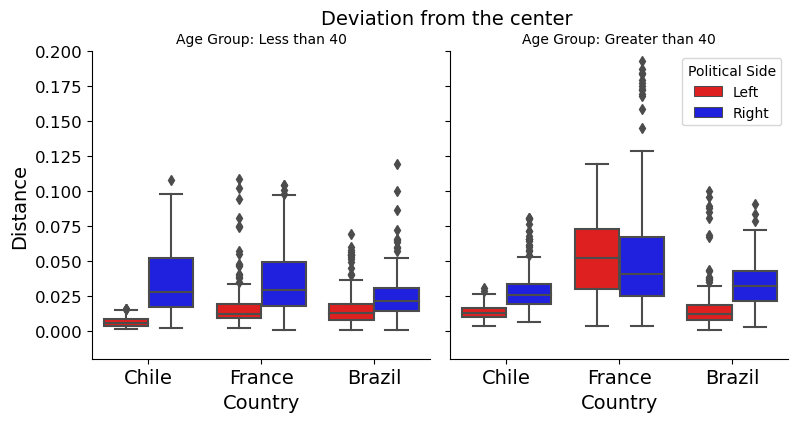

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame con todas las distancias
data = {
    'Country': ['France'] * (len(distancias_der_all_me) + len(distancias_iz_all_me) + len(distancias_der_all_ma) + len(distancias_iz_all_ma)) +
               ['Chile'] * (len(distancias_der_all_me_chile) + len(distancias_iz_all_me_chile) + len(distancias_der_all_ma_chile) + len(distancias_iz_all_ma_chile)) +
               ['Brazil'] * (len(distancias_der_all_me_brasil) + len(distancias_iz_all_me_brasil) + len(distancias_der_all_ma_brasil) + len(distancias_iz_all_ma_brasil)),

    'Age Group': ['Less than 40'] * len(distancias_der_all_me) + ['Less than 40'] * len(distancias_iz_all_me) +
                 ['Greater than 40'] * len(distancias_der_all_ma) + ['Greater than 40'] * len(distancias_iz_all_ma) +
                 ['Less than 40'] * len(distancias_der_all_me_chile) + ['Less than 40'] * len(distancias_iz_all_me_chile) +
                 ['Greater than 40'] * len(distancias_der_all_ma_chile) + ['Greater than 40'] * len(distancias_iz_all_ma_chile) +
                 ['Less than 40'] * len(distancias_der_all_me_brasil) + ['Less than 40'] * len(distancias_iz_all_me_brasil) +
                 ['Greater than 40'] * len(distancias_der_all_ma_brasil) + ['Greater than 40'] * len(distancias_iz_all_ma_brasil),

    'Political Side': ['Right'] * len(distancias_der_all_me) + ['Left'] * len(distancias_iz_all_me) +
                      ['Right'] * len(distancias_der_all_ma) + ['Left'] * len(distancias_iz_all_ma) +
                      ['Right'] * len(distancias_der_all_me_chile) + ['Left'] * len(distancias_iz_all_me_chile) +
                      ['Right'] * len(distancias_der_all_ma_chile) + ['Left'] * len(distancias_iz_all_ma_chile) +
                      ['Right'] * len(distancias_der_all_me_brasil) + ['Left'] * len(distancias_iz_all_me_brasil) +
                      ['Right'] * len(distancias_der_all_ma_brasil) + ['Left'] * len(distancias_iz_all_ma_brasil),

    'Distance': distancias_der_all_me + distancias_iz_all_me + distancias_der_all_ma + distancias_iz_all_ma +
                distancias_der_all_me_chile + distancias_iz_all_me_chile + distancias_der_all_ma_chile + distancias_iz_all_ma_chile +
                distancias_der_all_me_brasil + distancias_iz_all_me_brasil + distancias_der_all_ma_brasil + distancias_iz_all_ma_brasil
}



df = pd.DataFrame(data)

country_order=['Chile','France','Brazil']

# Reordering the 'Political Side' column to ensure 'Left' appears before 'Right'
df['Political Side'] = pd.Categorical(df['Political Side'], categories=['Left', 'Right'], ordered=True)

df_de=df.copy()

# Create the plot with adjusted order
g = sns.catplot(x='Country', y='Distance', hue='Political Side', col='Age Group', 
                data=df_de, kind='box', palette={'Left': 'red', 'Right': 'blue'}, 
                height=4, aspect=1, order=country_order)

# Adjust titles and axes
g.set_axis_labels('Country', 'Distance', fontsize=14)
g.set_xticklabels(fontsize=14)
g.set_titles(col_template="Age Group: {col_name}")
plt.suptitle('Deviation from the center', y=1.02, fontsize=14)
plt.ylim(-0.02, 0.20)

# Adjust the y-axis tick size
for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=12)

# Remove the automatic legend and place it in the upper right
g._legend.remove()
plt.legend(loc='upper right', title='Political Side', fontsize=10, title_fontsize=10)
plt.show()


In [11]:
distancias_der_chile = []
distancias_iz_chile = []

# Calcular la distancia para Chile (mayores de 40 y menores de 40)
for i in range(len(chile_mayores40_iz)):
    # Coordenadas para Chile (mayores de 40)
    z1_iz_ma_chile = chile_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_chile = chile_mayores40_iz.iloc[i]['z2']
    z1_der_ma_chile = chile_mayores40_der.iloc[i]['z1']
    z2_der_ma_chile = chile_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Chile (menores de 40)
    z1_iz_me_chile = chile_menores40_iz.iloc[i]['z1']
    z2_iz_me_chile = chile_menores40_iz.iloc[i]['z2']
    z1_der_me_chile = chile_menores40_der.iloc[i]['z1']
    z2_der_me_chile = chile_menores40_der.iloc[i]['z2']
    
    # Calcular distancias para Chile
    distancia_der_chile = np.sqrt((z1_der_me_chile - z1_der_ma_chile) ** 2 + (z2_der_me_chile - z2_der_ma_chile) ** 2)
    distancia_iz_chile = np.sqrt((z1_iz_me_chile - z1_iz_ma_chile) ** 2 + (z2_iz_me_chile - z2_iz_ma_chile) ** 2)

    # Agregar distancias a las listas
    distancias_der_chile.append(distancia_der_chile)
    distancias_iz_chile.append(distancia_iz_chile)


distancias_der_brasil = []
distancias_iz_brasil = []

# Calcular la distancia para Brasil (mayores de 40 y menores de 40)
for i in range(len(brasil_mayores40_iz)):
    # Coordenadas para Brasil (mayores de 40)
    z1_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z2']
    z1_der_ma_brasil = brasil_mayores40_der.iloc[i]['z1']
    z2_der_ma_brasil = brasil_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Brasil (menores de 40)
    z1_iz_me_brasil = brasil_menores40_iz.iloc[i]['z1']
    z2_iz_me_brasil = brasil_menores40_iz.iloc[i]['z2']
    z1_der_me_brasil = brasil_menores40_der.iloc[i]['z1']
    z2_der_me_brasil = brasil_menores40_der.iloc[i]['z2']
    
    # Calcular distancias para Brasil
    distancia_der_brasil = np.sqrt((z1_der_me_brasil - z1_der_ma_brasil) ** 2 + (z2_der_me_brasil - z2_der_ma_brasil) ** 2)
    distancia_iz_brasil = np.sqrt((z1_iz_me_brasil - z1_iz_ma_brasil) ** 2 + (z2_iz_me_brasil - z2_iz_ma_brasil) ** 2)

    # Agregar distancias a las listas
    distancias_der_brasil.append(distancia_der_brasil)
    distancias_iz_brasil.append(distancia_iz_brasil)


    
distancias_der_francia = []
distancias_iz_francia = []

# Calcular la distancia para Francia (mayores de 40 y menores de 40)
for i in range(len(francia_mayores40_iz)):
    # Coordenadas para Francia (mayores de 40)
    z1_iz_ma_francia = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_francia = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma_francia = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma_francia = francia_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Francia (menores de 40)
    z1_iz_me_francia = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me_francia = francia_menores40_iz.iloc[i]['z2']
    z1_der_me_francia = francia_menores40_der.iloc[i]['z1']
    z2_der_me_francia = francia_menores40_der.iloc[i]['z2']
    
    # Calcular distancias para Francia
    distancia_der_francia = np.sqrt((z1_der_me_francia - z1_der_ma_francia) ** 2 + (z2_der_me_francia - z2_der_ma_francia) ** 2)
    distancia_iz_francia = np.sqrt((z1_iz_me_francia - z1_iz_ma_francia) ** 2 + (z2_iz_me_francia - z2_iz_ma_francia) ** 2)

    # Agregar distancias a las listas
    distancias_der_francia.append(distancia_der_francia)
    distancias_iz_francia.append(distancia_iz_francia)


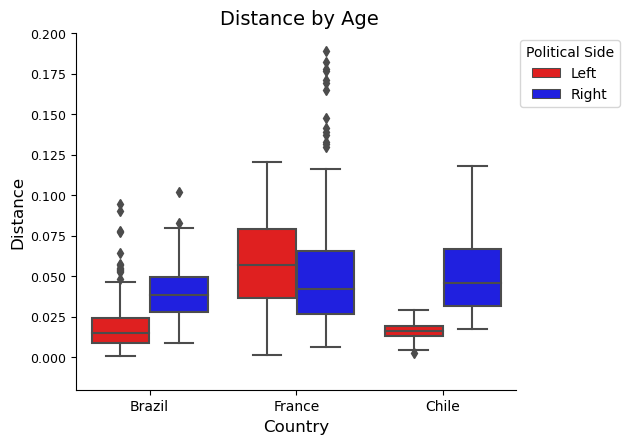

In [12]:
# Crear un DataFrame con todas las distancias
df_distance_by_age = {
    'Country': ['Brazil'] * len(distancias_iz_brasil) + ['Brazil'] * len(distancias_der_brasil) + \
               ['France'] * len(distancias_iz_francia) + ['France'] * len(distancias_der_francia)+ \
               ['Chile'] * len(distancias_iz_chile) + ['Chile'] * len(distancias_der_chile),
               
               
    
    'Political Side': ['Left'] * len(distancias_iz_brasil) + ['Right'] * len(distancias_der_brasil) + \
                    ['Left'] * len(distancias_iz_francia) + ['Right'] * len(distancias_der_francia) + \
                    ['Left'] * len(distancias_iz_chile) + ['Right'] * len(distancias_der_chile),
                      
                      
    
    'Distance':  distancias_iz_brasil +  distancias_der_brasil + \
                distancias_iz_francia + distancias_der_francia + \
                distancias_iz_chile + distancias_der_chile
                
}

df_distance_by_age = pd.DataFrame(df_distance_by_age)

# Definir el orden de los países y los lados políticos
political_side_order = ['Left', 'Right']
country_order = ['Brazil', 'France','Chile']

# Crear facetas para las distancias
g = sns.catplot(x='Country', y='Distance', hue='Political Side', 
                data=df_distance_by_age, kind='box', palette={'Left': 'red', 'Right': 'blue'}, 
                 height=4.3, aspect=1.27, order=country_order)

# Ajustar títulos y ejes
g.set_axis_labels('Country', 'Distance', fontsize=12)
plt.suptitle('Distance by Age', y=1.02, fontsize=14)
plt.ylim(-0.02, 0.20)


for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=9)  # Ajusta el tamaño de las etiquetas en el eje y

# Eliminar la leyenda automática
g._legend.remove()

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), title='Political Side', 
           fontsize=10, title_fontsize=10)


## Chile

In [13]:

# Cargar datos de cada generación
generation_z = pd.read_excel('Coordenadas/Coordenadas_peaks_Generation Z (Centennials).xlsx')
generation_y = pd.read_excel('Coordenadas/Coordenadas_peaks_Generation Y (Millennials).xlsx')
generation_x = pd.read_excel('Coordenadas/Coordenadas_peaks_Generation X.xlsx')
baby_boomers = pd.read_excel('Coordenadas/Coordenadas_peaks_Baby Boomers.xlsx')
silent_generation = pd.read_excel('Coordenadas/Coordenadas_peaks_Silent Generation.xlsx')

# Filtrar por política para cada generación
generation_z_der = generation_z[generation_z['Politica'] == 'Right']
generation_z_iz = generation_z[generation_z['Politica'] == 'Left']

generation_y_der = generation_y[generation_y['Politica'] == 'Right']
generation_y_iz = generation_y[generation_y['Politica'] == 'Left']

generation_x_der = generation_x[generation_x['Politica'] == 'Right']
generation_x_iz = generation_x[generation_x['Politica'] == 'Left']

baby_boomers_der = baby_boomers[baby_boomers['Politica'] == 'Right']
baby_boomers_iz = baby_boomers[baby_boomers['Politica'] == 'Left']

silent_generation_der = silent_generation[silent_generation['Politica'] == 'Right']
silent_generation_iz = silent_generation[silent_generation['Politica'] == 'Left']

In [14]:
distancias_genz = []
# Calcular la distancia entre todas las filas
for i in range(len(chile_mayores40_iz)):
    z1_iz_genz = generation_z_iz.iloc[i]['z1']
    z2_iz_genz = generation_z_iz.iloc[i]['z2']
    
    z1_der_genz = generation_z_der.iloc[i]['z1']
    z2_der_genz = generation_z_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_genz = np.sqrt((z1_der_genz - z1_iz_genz) ** 2 + (z2_der_genz - z2_iz_genz) ** 2)

    
    # Agregar la distancia a la lista
    distancias_genz.append(distancia_genz)
    
    import numpy as np

# Listas para almacenar distancias de cada generación
distancias_genz = []
distancias_geny = []
distancias_genx = []
distancias_baby_boomers = []
distancias_silent = []

# Calcular la distancia para Generation Z
for i in range(len(generation_z_iz)):
    z1_iz_genz = generation_z_iz.iloc[i]['z1']
    z2_iz_genz = generation_z_iz.iloc[i]['z2']
    
    z1_der_genz = generation_z_der.iloc[i]['z1']
    z2_der_genz = generation_z_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_genz = np.sqrt((z1_der_genz - z1_iz_genz) ** 2 + (z2_der_genz - z2_iz_genz) ** 2)

    # Agregar la distancia a la lista
    distancias_genz.append(distancia_genz)

# Calcular la distancia para Generation Y (Millennials)
for i in range(len(generation_y_iz)):
    z1_iz_geny = generation_y_iz.iloc[i]['z1']
    z2_iz_geny = generation_y_iz.iloc[i]['z2']
    
    z1_der_geny = generation_y_der.iloc[i]['z1']
    z2_der_geny = generation_y_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_geny = np.sqrt((z1_der_geny - z1_iz_geny) ** 2 + (z2_der_geny - z2_iz_geny) ** 2)

    # Agregar la distancia a la lista
    distancias_geny.append(distancia_geny)

# Calcular la distancia para Generation X
for i in range(len(generation_x_iz)):
    z1_iz_genx = generation_x_iz.iloc[i]['z1']
    z2_iz_genx = generation_x_iz.iloc[i]['z2']
    
    z1_der_genx = generation_x_der.iloc[i]['z1']
    z2_der_genx = generation_x_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_genx = np.sqrt((z1_der_genx - z1_iz_genx) ** 2 + (z2_der_genx - z2_iz_genx) ** 2)

    # Agregar la distancia a la lista
    distancias_genx.append(distancia_genx)

# Calcular la distancia para Baby Boomers
for i in range(len(baby_boomers_iz)):
    z1_iz_baby = baby_boomers_iz.iloc[i]['z1']
    z2_iz_baby = baby_boomers_iz.iloc[i]['z2']
    
    z1_der_baby = baby_boomers_der.iloc[i]['z1']
    z2_der_baby = baby_boomers_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_baby = np.sqrt((z1_der_baby - z1_iz_baby) ** 2 + (z2_der_baby - z2_iz_baby) ** 2)

    # Agregar la distancia a la lista
    distancias_baby_boomers.append(distancia_baby)

# Calcular la distancia para Silent Generation
for i in range(len(silent_generation_iz)):
    z1_iz_silent = silent_generation_iz.iloc[i]['z1']
    z2_iz_silent = silent_generation_iz.iloc[i]['z2']
    
    z1_der_silent = silent_generation_der.iloc[i]['z1']
    z2_der_silent = silent_generation_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_silent = np.sqrt((z1_der_silent - z1_iz_silent) ** 2 + (z2_der_silent - z2_iz_silent) ** 2)

    # Agregar la distancia a la lista
    distancias_silent.append(distancia_silent)

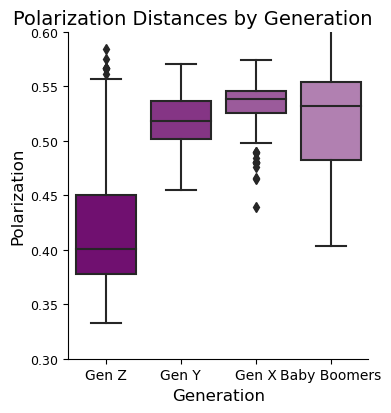

In [15]:
# Crear DataFrame para catplot con generaciones

# Combinar las distancias de Baby Boomers y Silent Generation
distancias_baby_silent = distancias_baby_boomers + distancias_silent


data_gen = {
    'Generation': (
        ['Gen Z'] * len(distancias_genz) +
        ['Gen Y'] * len(distancias_geny) +
        ['Gen X'] * len(distancias_genx) +
        ['Baby Boomers'] * len(distancias_baby_silent)
    ),
    'Distance': np.concatenate([
        distancias_genz,
        distancias_geny,
        distancias_genx,
        distancias_baby_silent
    ])
}

df_gen = pd.DataFrame(data_gen)

purple_palette = sns.light_palette("purple", n_colors=7, reverse=True)


# Crear gráfico tipo catplot con el mismo estilo que los anteriores
g = sns.catplot(x='Generation', y='Distance',
                data=df_gen, kind='box', palette=purple_palette,
                order=['Gen Z', 'Gen Y', 'Gen X', 'Baby Boomers'],
                height=4, aspect=1)

# Ajustar títulos y ejes
g.set_axis_labels('Generation', 'Polarization', fontsize=12)
plt.suptitle('Polarization Distances by Generation', y=1.02, fontsize=14)
plt.ylim(0.30, 0.60)

# Ajustar tamaño de etiquetas del eje y
for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=9)



In [16]:
import numpy as np

# Suponiendo que ya tienes los DataFrames correspondientes para cada generación
# Asegúrate de que estos DataFrames existen y contienen las columnas 'z1' y 'z2'

# Listas para almacenar las distancias
distancias_der_all_genz = []
distancias_iz_all_genz = []

distancias_der_all_geny = []
distancias_iz_all_geny = []

distancias_der_all_genx = []
distancias_iz_all_genx = []

# Supongamos que has unido Baby Boomers y Silent Generation
distancias_der_all_silent = []
distancias_iz_all_silent = []

# Supongamos que has unido Baby Boomers y Silent Generation
distancias_der_all_baby = []
distancias_iz_all_baby = []

# Calcular las distancias para Generación Z
for i in range(len(generation_z_iz)):
    z1_iz_genz = generation_z_iz.iloc[i]['z1']
    z2_iz_genz = generation_z_iz.iloc[i]['z2']
    
    z1_der_genz = generation_z_der.iloc[i]['z1']
    z2_der_genz = generation_z_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_genz = np.sqrt((z1_der_all - z1_der_genz) ** 2 + (z2_der_all - z2_der_genz) ** 2)
    distancia_iz_all_genz = np.sqrt((z1_iz_all - z1_iz_genz) ** 2 + (z2_iz_all - z2_iz_genz) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_genz.append(distancia_der_all_genz)
    distancias_iz_all_genz.append(distancia_iz_all_genz)

# Calcular las distancias para Generación Y (Millennials)
for i in range(len(generation_y_iz)):  # Asegúrate de que tienes este DataFrame
    z1_iz_geny = generation_y_iz.iloc[i]['z1']
    z2_iz_geny = generation_y_iz.iloc[i]['z2']
    
    z1_der_geny = generation_y_der.iloc[i]['z1']
    z2_der_geny = generation_y_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_geny = np.sqrt((z1_der_all - z1_der_geny) ** 2 + (z2_der_all - z2_der_geny) ** 2)
    distancia_iz_all_geny = np.sqrt((z1_iz_all - z1_iz_geny) ** 2 + (z2_iz_all - z2_iz_geny) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_geny.append(distancia_der_all_geny)
    distancias_iz_all_geny.append(distancia_iz_all_geny)

# Calcular las distancias para Generación X
for i in range(len(generation_x_iz)):  # Asegúrate de que tienes este DataFrame
    z1_iz_genx = generation_x_iz.iloc[i]['z1']
    z2_iz_genx = generation_x_iz.iloc[i]['z2']
    
    z1_der_genx = generation_x_der.iloc[i]['z1']
    z2_der_genx = generation_x_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_genx = np.sqrt((z1_der_all - z1_der_genx) ** 2 + (z2_der_all - z2_der_genx) ** 2)
    distancia_iz_all_genx = np.sqrt((z1_iz_all - z1_iz_genx) ** 2 + (z2_iz_all - z2_iz_genx) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_genx.append(distancia_der_all_genx)
    distancias_iz_all_genx.append(distancia_iz_all_genx)

# Calcular las distancias para Baby Boomers y Silent Generation
for i in range(len(silent_generation_iz)):  # Asegúrate de que tienes este DataFrame combinado
    z1_iz_silent = silent_generation_iz.iloc[i]['z1']
    z2_iz_silent = silent_generation_iz.iloc[i]['z2']
    
    z1_der_silent = silent_generation_der.iloc[i]['z1']
    z2_der_silent = silent_generation_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_silent = np.sqrt((z1_der_all - z1_der_silent) ** 2 + (z2_der_all - z2_der_silent) ** 2)
    distancia_iz_all_silent = np.sqrt((z1_iz_all - z1_iz_silent) ** 2 + (z2_iz_all - z2_iz_silent) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_silent.append(distancia_der_all_silent)
    distancias_iz_all_silent.append(distancia_iz_all_silent)

    
    
    
# Calcular las distancias para Baby Boomers y Silent Generation
for i in range(len(baby_boomers_der)):  # Asegúrate de que tienes este DataFrame combinado
    z1_iz_baby = baby_boomers_iz.iloc[i]['z1']
    z2_iz_baby= baby_boomers_iz.iloc[i]['z2']
    
    z1_der_baby = baby_boomers_der.iloc[i]['z1']
    z2_der_baby = baby_boomers_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_baby = np.sqrt((z1_der_all - z1_der_baby) ** 2 + (z2_der_all - z2_der_baby) ** 2)
    distancia_iz_all_baby = np.sqrt((z1_iz_all - z1_iz_baby) ** 2 + (z2_iz_all - z2_iz_baby) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_baby.append(distancia_der_all_baby)
    distancias_iz_all_baby.append(distancia_iz_all_baby)



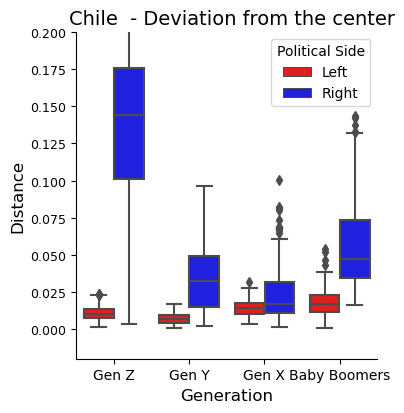

In [17]:

# Combinar las distancias de Baby Boomers y Silent Generation
distancias_der_all_baby_silent = distancias_der_all_silent + distancias_der_all_baby 
distancias_iz_all_baby_silent = distancias_iz_all_silent + distancias_iz_all_baby 
# Crear un DataFrame con todas las distancias
data_u = {
    'Generation': ['Gen Z'] * len(distancias_der_all_genz) + ['Gen Z'] * len(distancias_iz_all_genz) + \
                  ['Gen Y'] * len(distancias_der_all_geny) + ['Gen Y'] * len(distancias_iz_all_geny) + \
                  ['Gen X'] * len(distancias_der_all_genx) + ['Gen X'] * len(distancias_iz_all_genx) + \
                  ['Baby Boomers'] * len(distancias_der_all_baby_silent) + ['Baby Boomers'] * len(distancias_iz_all_baby_silent),
    
    'Political Side': ['Left'] * len(distancias_iz_all_genz) + ['Right'] * len(distancias_der_all_genz) + \
                      ['Left'] * len(distancias_iz_all_geny) + ['Right'] * len(distancias_der_all_geny) + \
                      ['Left'] * len(distancias_iz_all_genx) + ['Right'] * len(distancias_der_all_genx) + \
                      ['Left'] * len(distancias_iz_all_baby_silent) + ['Right'] * len(distancias_der_all_baby_silent),
    
    'Distance': distancias_iz_all_genz + distancias_der_all_genz + \
                distancias_iz_all_geny + distancias_der_all_geny + \
                distancias_iz_all_genx + distancias_der_all_genx + \
                distancias_iz_all_baby_silent + distancias_der_all_baby_silent
}

df_u = pd.DataFrame(data_u)


# Definir el orden de las generaciones y los lados políticos

political_side_order = ['Left', 'Right']


# Crear facetas para las distancias
g = sns.catplot(x='Generation', y='Distance', hue='Political Side', 
                data=df_u, kind='box', palette={'Left': 'red', 'Right': 'blue'}, 
                height=4, aspect=1)

# Ajustar títulos y ejes
g.set_axis_labels('Generation', 'Distance',fontsize=12)
plt.suptitle('Chile  - Deviation from the center', y=1.02,fontsize=14)
plt.ylim(-0.02, 0.20)


for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=9)  # Ajusta el tamaño de las etiquetas en el eje y

# Eliminar la leyenda automática
g._legend.remove()

plt.legend(loc='upper right', bbox_to_anchor=(1, 1), title='Political Side', 
           fontsize=10, title_fontsize=10)

### Subplot

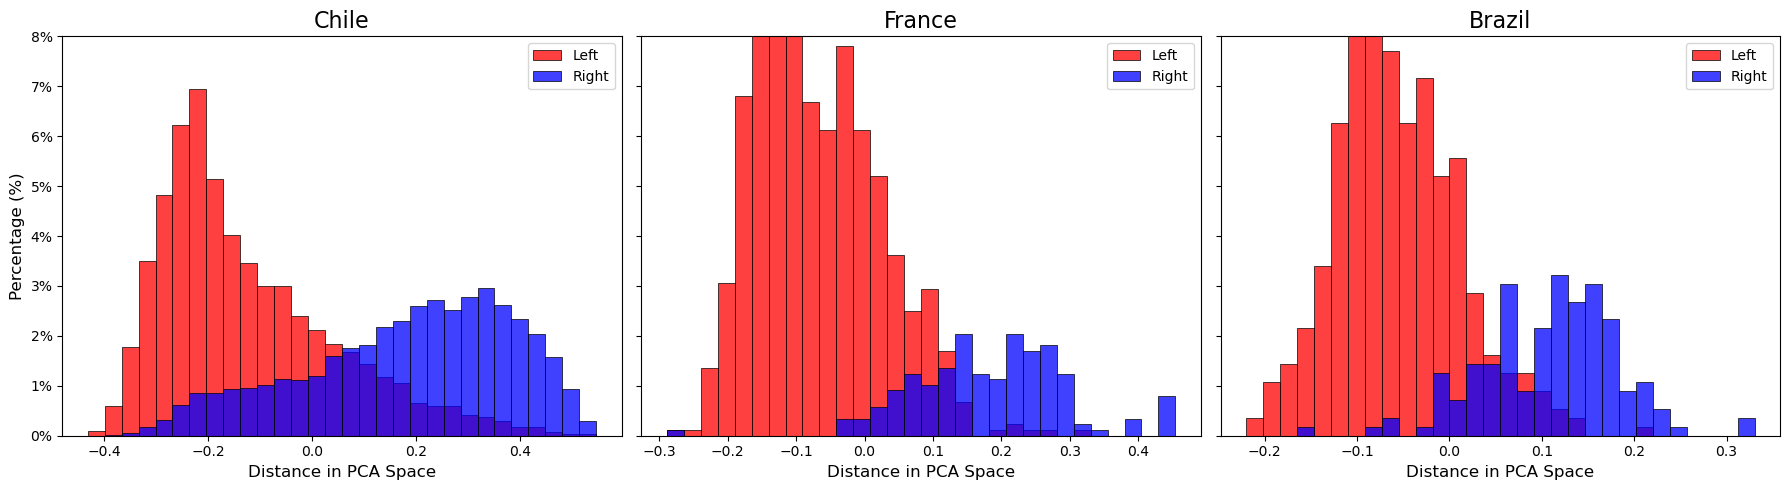

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Load the exported data ---
df = pd.read_csv('Coordenadas/distancias_pca_data.csv')

# --- Define plotting parameters ---
num_bins = 30
countries = df['Country'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, country in zip(axes, countries):
    df_country = df[df['Country'] == country]
    left = df_country[df_country['Political Side'] == 'Left']['Distance'].values
    right = df_country[df_country['Political Side'] == 'Right']['Distance'].values

    all_values = np.concatenate([left, right])
    bin_edges = np.histogram_bin_edges(all_values, bins=num_bins)
    total_count = len(all_values)

    weights_left = np.ones_like(left) / total_count
    weights_right = np.ones_like(right) / total_count

    sns.histplot(x=left, bins=bin_edges, weights=weights_left,
                 color='red', label='Left', ax=ax, fill=True, edgecolor='black', linewidth=0.5)
    sns.histplot(x=right, bins=bin_edges, weights=weights_right,
                 color='blue', label='Right', ax=ax, fill=True, edgecolor='black', linewidth=0.5)

    ax.set_ylim(0, max(ax.get_ylim()))
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

    ax.set_title(country, fontsize=16)
    ax.set_xlabel('Distance in PCA Space', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

# All

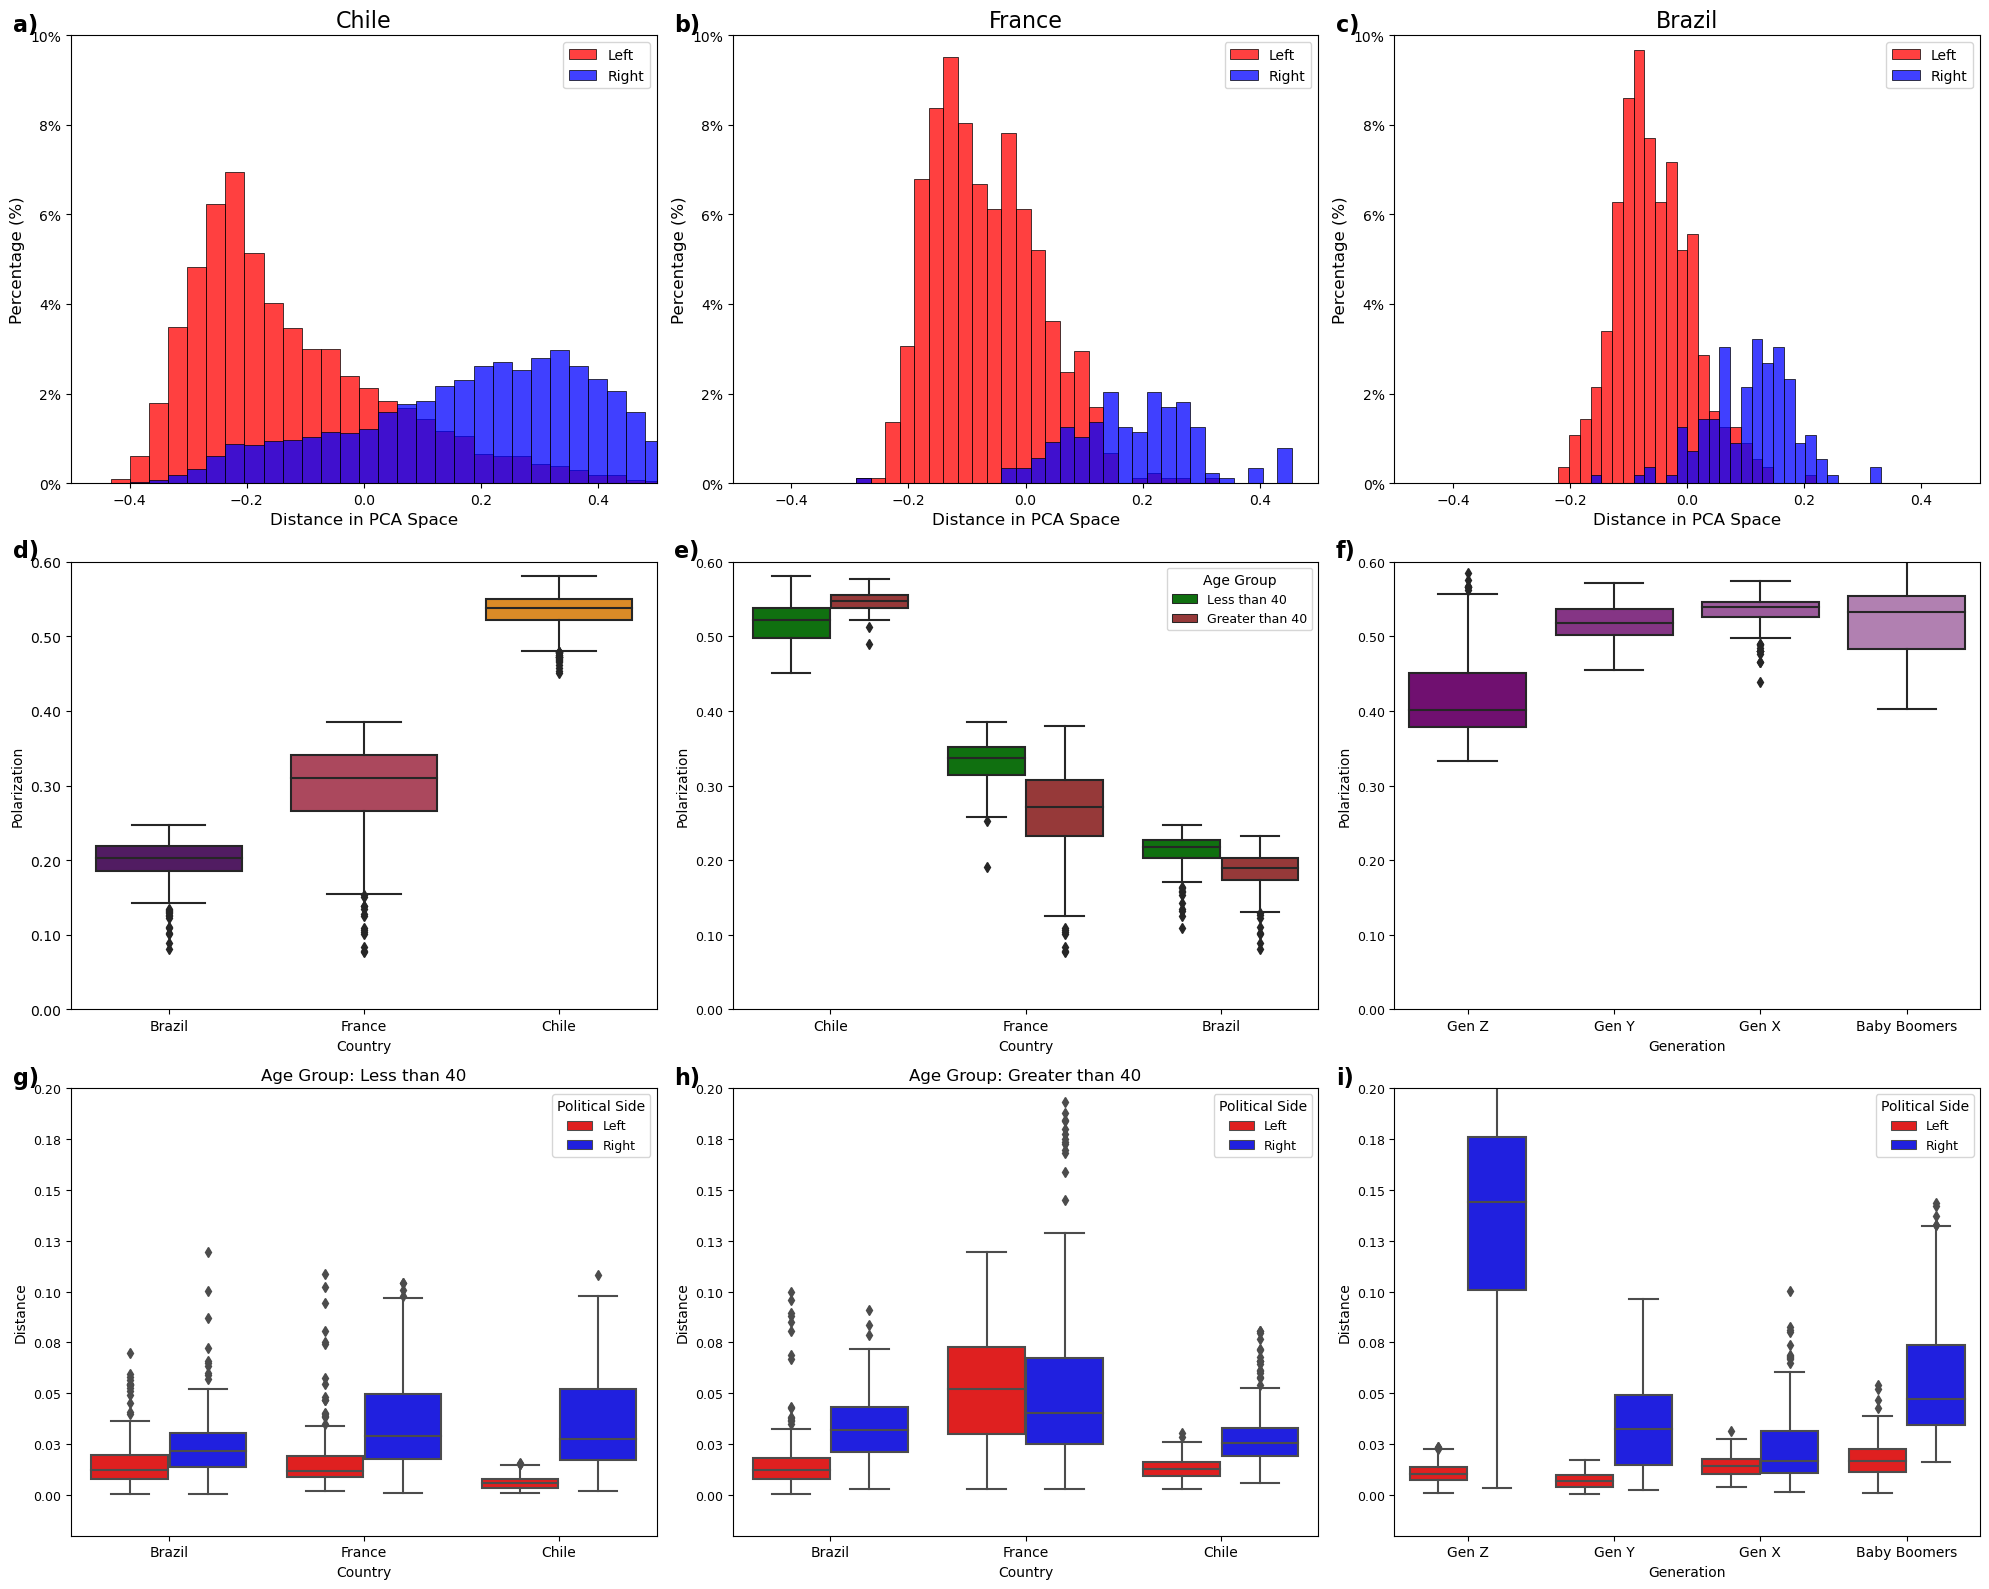

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the exported data ---
df = pd.read_csv('Coordenadas/distancias_pca_data.csv')

# --- Define plotting parameters ---
num_bins = 30
countries = df['Country'].unique()

# Crear nueva figura con GridSpec 3x3
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3)

# --- Plots a, b, c: Histogramas con y fijo de 0 a 10% ---
for i, country in enumerate(countries):
    ax = fig.add_subplot(gs[0, i])
    df_country = df[df['Country'] == country]
    left = df_country[df_country['Political Side'] == 'Left']['Distance'].values
    right = df_country[df_country['Political Side'] == 'Right']['Distance'].values

    all_values = np.concatenate([left, right])
    bin_edges = np.histogram_bin_edges(all_values, bins=num_bins)
    total_count = len(all_values)

    weights_left = np.ones_like(left) / total_count
    weights_right = np.ones_like(right) / total_count

    sns.histplot(x=left, bins=bin_edges, weights=weights_left,
                 color='red', label='Left', ax=ax, fill=True, edgecolor='black', linewidth=0.5)
    sns.histplot(x=right, bins=bin_edges, weights=weights_right,
                 color='blue', label='Right', ax=ax, fill=True, edgecolor='black', linewidth=0.5)

    ax.set_ylim(0, 0.10)
    ax.set_xlim(-0.5, 0.5)  
    ax.set_yticks(np.linspace(0, 0.10, 6))
    ax.set_yticklabels([f'{int(y*100)}%' for y in np.linspace(0, 0.10, 6)])

    ax.set_title(country, fontsize=16)
    ax.set_xlabel('Distance in PCA Space', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.legend()
    ax.text(-0.1, 1.05, f"{chr(97+i)})", transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')

# --- Plot d ---
ax_d = fig.add_subplot(gs[1, 0])
sns.boxplot(
    x='Country', y='Distance', data=df_a,
    order=country_order, palette='inferno', width=0.75, ax=ax_d
)
ax_d.set_ylabel("Polarization")
ax_d.set_xlabel("Country")
ax_d.set_ylim(0.00, 0.60)
ax_d.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax_d.text(-0.1, 1.05, "d)", transform=ax_d.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='left')

# --- Plot e ---
ax_e = fig.add_subplot(gs[1, 1])
sns.boxplot(
    x='Country', y='Distance', hue='Age Group', data=df_b,
    palette={'Less than 40': 'green', 'Greater than 40': 'brown'}, ax=ax_e
)
ax_e.legend(title='Age Group', title_fontsize=10, fontsize=9, loc='upper right')
ax_e.set_ylabel("Polarization")
ax_e.set_xlabel("Country")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax_e.tick_params(axis='y', labelsize=9)
ax_e.text(-0.1, 1.05, "e)", transform=ax_e.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='left')

# --- Plot f ---
ax_f = fig.add_subplot(gs[1, 2])
purple_palette = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x='Generation', y='Distance', data=df_gen,
    order=['Gen Z', 'Gen Y', 'Gen X', 'Baby Boomers'],
    palette=purple_palette, ax=ax_f
)
ax_f.set_ylabel("Polarization")
ax_f.set_xlabel("Generation")
ax_f.set_ylim(0.00, 0.60)
ax_f.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax_f.tick_params(axis='y', labelsize=9)
ax_f.text(-0.1, 1.05, "f)", transform=ax_f.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='left')

# --- Plot g ---
ax_g = fig.add_subplot(gs[2, 0])
data_g = df_de[df_de['Age Group'] == 'Less than 40']
sns.boxplot(
    x='Country',
    y='Distance',
    hue='Political Side',
    data=data_g,
    palette={'Left': 'red', 'Right': 'blue'},
    order=country_order,
    ax=ax_g
)
ax_g.set_title(f"Age Group: Less than 40")
ax_g.set_ylim(-0.02, 0.20)
ax_g.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax_g.tick_params(axis='y', labelsize=9)
ax_g.set_xlabel("Country")
ax_g.set_ylabel("Distance")
ax_g.legend(title='Political Side', title_fontsize=10, fontsize=9, loc='upper right')
ax_g.text(-0.1, 1.05, "g)", transform=ax_g.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='left')

# --- Plot h ---
ax_h = fig.add_subplot(gs[2, 1])
data_h = df_de[df_de['Age Group'] == 'Greater than 40']
sns.boxplot(
    x='Country',
    y='Distance',
    hue='Political Side',
    data=data_h,
    palette={'Left': 'red', 'Right': 'blue'},
    order=country_order,
    ax=ax_h
)
ax_h.set_title(f"Age Group: Greater than 40")
ax_h.set_ylim(-0.02, 0.20)
ax_h.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax_h.tick_params(axis='y', labelsize=9)
ax_h.set_xlabel("Country")
ax_h.set_ylabel("Distance")
ax_h.legend(title='Political Side', title_fontsize=10, fontsize=9, loc='upper right')
ax_h.text(-0.1, 1.05, "h)", transform=ax_h.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='left')

# --- Plot i ---
ax_i = fig.add_subplot(gs[2, 2])
sns.boxplot(
    x='Generation',
    y='Distance',
    hue='Political Side',
    data=df_u,
    order=['Gen Z', 'Gen Y', 'Gen X', 'Baby Boomers'],
    palette={'Left': 'red', 'Right': 'blue'},
    ax=ax_i
)
ax_i.legend(title='Political Side', title_fontsize=10, fontsize=9, loc='upper right')
ax_i.set_ylabel("Distance")
ax_i.set_xlabel("Generation")
ax_i.set_ylim(-0.02, 0.20)
ax_i.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax_i.tick_params(axis='y', labelsize=9)
ax_i.text(-0.1, 1.05, "i)", transform=ax_i.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()
fig.savefig("Fig3.svg", format="svg")



### New Fig 3

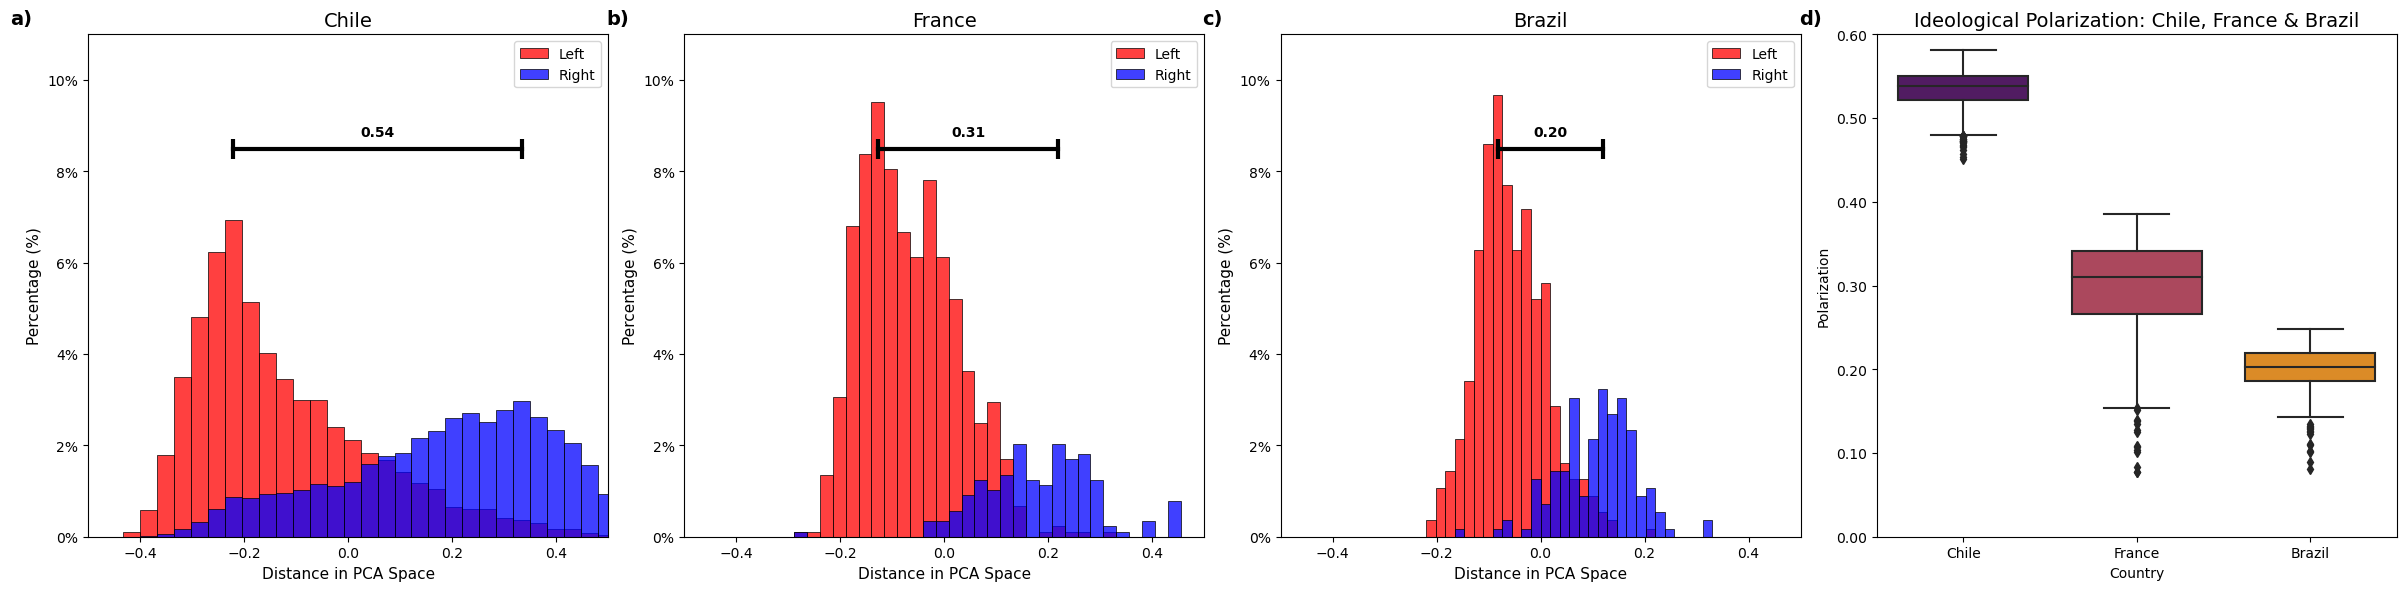

In [20]:
# Fig. 3 abcd – Polarisation histograms (a-c) + box-plot (d)
# ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------------
df = pd.read_csv("Coordenadas/distancias_pca_data.csv")

# Standardise capitalisation (optional – remove if not needed)
df["Country"] = df["Country"].str.title()

# ---------------------------------------------------------------------------
# 2. Pre-compute median (50 %) value per country ––––––––––––––––––––––––––––
median_by_country = df_a.groupby("Country")["Distance"].median()


# ---------------------------------------------------------------------------
# 2. Figure layout
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 4, figsize=(24, 6),
    gridspec_kw={"width_ratios": [1, 1, 1, 1]}
)

# ---- constants ----------------------------------------------------------------
countries        = ["Chile", "France", "Brazil"]        # a-, b-, c-panels
country_order_d  = ["Chile", "France", "Brazil"]        # d-panel (box-plot)
num_bins         = 30
pca_min, pca_max = -0.5, 0.5

# ---------------------------------------------------------------------------
# 3. Panels a–c  : histogram + distance indicator
# ---------------------------------------------------------------------------
for i, country in enumerate(countries):
    ax    = axes[i]
    df_c  = df[df["Country"] == country]

    left   = df_c[df_c["Political Side"] == "Left"]["Distance"].values
    right  = df_c[df_c["Political Side"] == "Right"]["Distance"].values
    all_d  = np.concatenate([left, right])

    bin_edges     = np.histogram_bin_edges(all_d, bins=num_bins)
    total_count   = len(all_d)
    weights_left  = np.ones_like(left)  / total_count
    weights_right = np.ones_like(right) / total_count

    sns.histplot(x=left,  bins=bin_edges, weights=weights_left,
                 color="red",  fill=True, edgecolor="black", linewidth=0.5,
                 label="Left",  ax=ax)
    sns.histplot(x=right, bins=bin_edges, weights=weights_right,
                 color="blue", fill=True, edgecolor="black", linewidth=0.5,
                 label="Right", ax=ax)

    # ── axis cosmetics ──────────────────────────────────────────────────────
    ax.set_ylim(0, 0.11)                       # ← raised a bit
    ax.set_xlim(pca_min, pca_max)
    ax.set_yticks(np.linspace(0, 0.10, 6))
    ax.set_yticklabels([f"{int(y*100)}%" for y in np.linspace(0, 0.10, 6)])
    ax.set_title(country, fontsize=14)
    ax.set_xlabel("Distance in PCA Space", fontsize=11)
    ax.set_ylabel("Percentage (%)",       fontsize=11)
    ax.legend()
    ax.text(-0.15, 1.05, f"{chr(97+i)})", transform=ax.transAxes,
            fontsize=14, fontweight="bold", ha="left", va="top")

    # ── distance indicator (horizontal segment) ─────────────────────────────
    left_counts,  _ = np.histogram(left,  bins=bin_edges, weights=weights_left)
    right_counts, _ = np.histogram(right, bins=bin_edges, weights=weights_right)
    bin_centers     = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    peak_left   = bin_centers[np.argmax(left_counts)]
    peak_right  = bin_centers[np.argmax(right_counts)]

    y_line  = 0.085
    y_text  = 0.087
    ax.plot([peak_left, peak_right], [y_line, y_line],
            color="k", linewidth=3, marker='|', markersize=15,
            zorder=6, markeredgewidth=3)
    
    # numeric annotation → median value from panel d -----------------------
    median_val = median_by_country[country]
    ax.text((peak_left + peak_right) / 2, y_text,
            f"{median_val:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# ---------------------------------------------------------------------------
# 4. Panel d  : polarisation box-plot
# ---------------------------------------------------------------------------

country_order = ["Chile", "France", "Brazil"]   # desired left-to-right order

# Tell pandas that the Country column is ordered this way
df_a = df_a.copy()                              # keep original df_a intact
df_a["Country"] = pd.Categorical(
    df_a["Country"],
    categories=country_order,
    ordered=True
)

ax_d = axes[3]
sns.boxplot(
    x="Country", y="Distance",
    data=df_a,                   # ***exactly the same values as before***
    palette="inferno",
    width=0.75,
    ax=ax_d
)

ax_d.set_title("Ideological Polarization: Chile, France & Brazil", fontsize=14)
ax_d.set_ylabel("Polarization")
ax_d.set_xlabel("Country")
ax_d.set_ylim(0.00, 0.60)
ax_d.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_d.text(-0.15, 1.05, "d)", transform=ax_d.transAxes,
          fontsize=14, fontweight="bold", ha="left", va="top")

# ---------------------------------------------------------------------------
# 5. Layout & export
# ---------------------------------------------------------------------------
plt.tight_layout()
plt.show()
fig.savefig("Fig3_abcd.svg", format="svg")

### New Fig 4

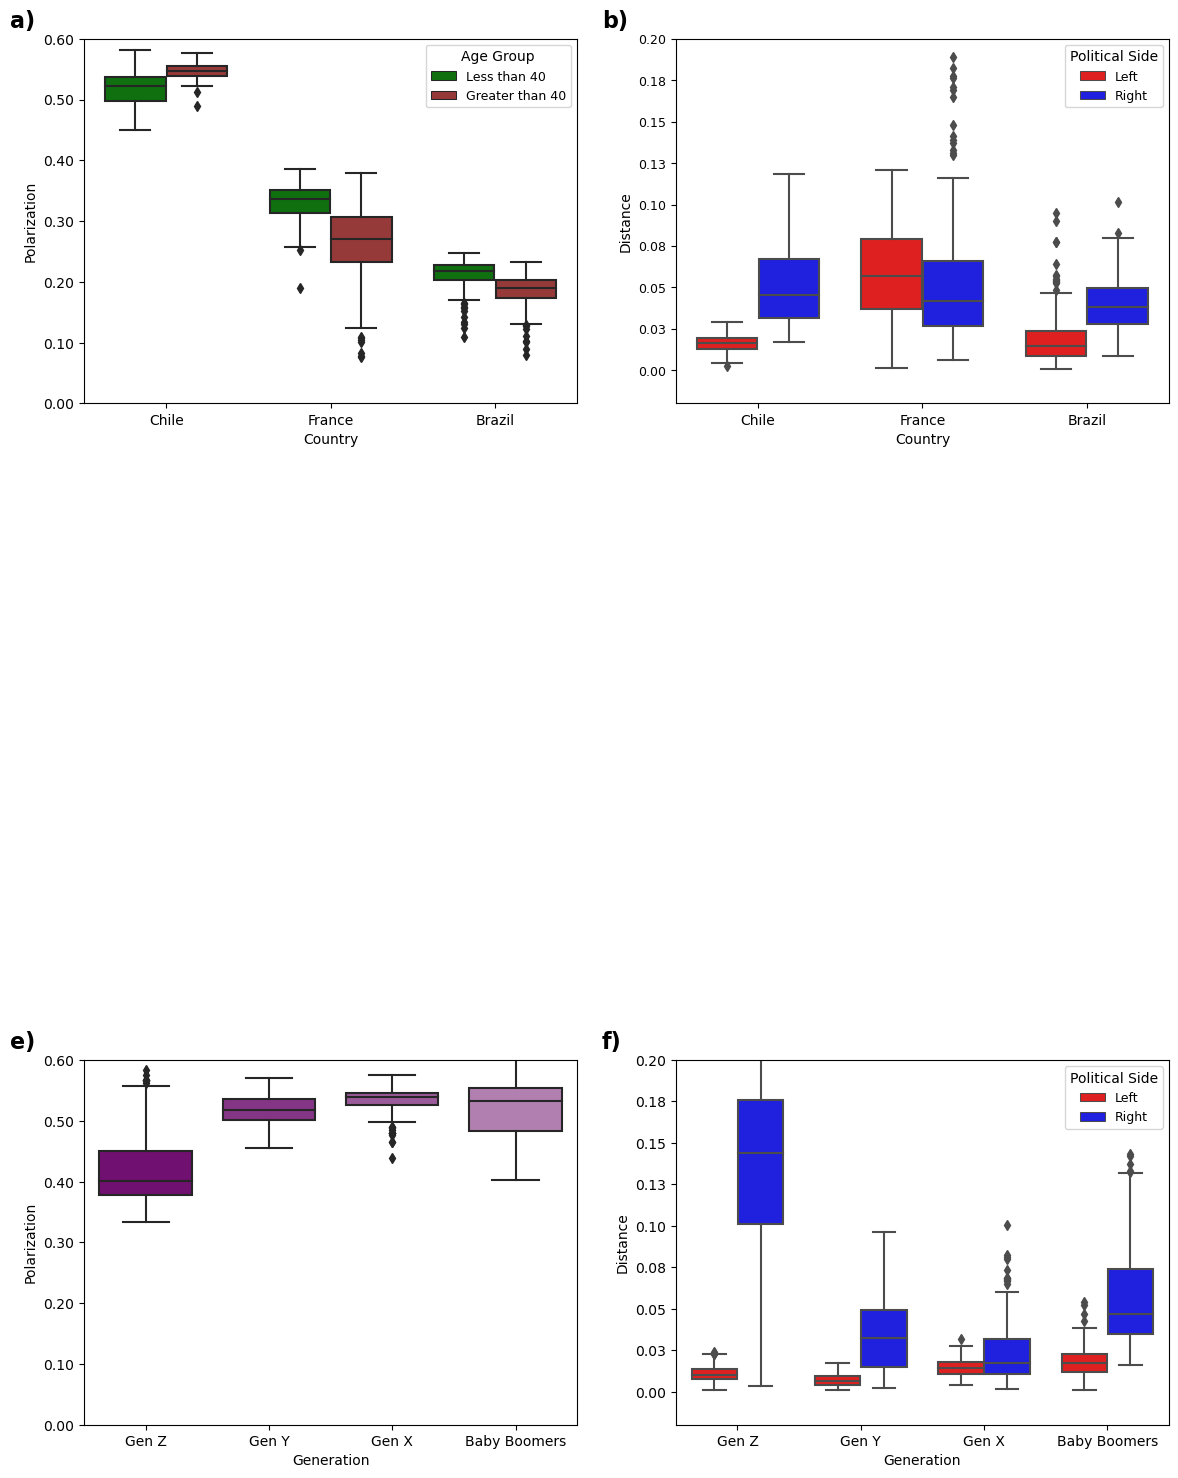

In [21]:
# ──────────────────────────────────────────────────────────────────
#  Fig 4  : 3 rows × 2 cols
#  a  → df_b   (Age-Group × Country, reorder to Chile-France-Brazil)
#  b  → df_distance_by_age (Political-Side × Country, same order)
#  e  → df_gen (Generation)
#  f  → df_u   (Generation × Political-Side)
#  other cells left blank
# ──────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

fig4 = plt.figure(figsize=(14, 18))
gs4  = fig4.add_gridspec(3, 2, wspace=0.2, hspace=0.4)

# custom country order for panels a & b
order_ab = ["Chile", "France", "Brazil"]

# ── a)  (old panel e) ────────────────────────────────────────────
ax_a = fig4.add_subplot(gs4[0, 0])
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=order_ab, width=0.75, ax=ax_a
)
ax_a.set_ylabel("Polarization")
ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_a.text(-0.15, 1.08, "a)", transform=ax_a.transAxes,
          fontsize=16, fontweight="bold", va="top", ha="left")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ── b)  (new plot) ───────────────────────────────────────────────
ax_b = fig4.add_subplot(gs4[0, 1])
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=order_ab, width=0.75, ax=ax_b
)
ax_b.set_ylabel("Distance")
ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_b.text(-0.15, 1.08, "b)", transform=ax_b.transAxes,
          fontsize=16, fontweight="bold", va="top", ha="left")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ── blank middle row ─────────────────────────────────────────────
for c in [0, 1]:
    fig4.add_subplot(gs4[1, c]).axis("off")

# ── e)  (old panel f) ────────────────────────────────────────────
ax_e = fig4.add_subplot(gs4[2, 0])
purple_palette = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple_palette, width=0.75, ax=ax_e
)
ax_e.set_ylabel("Polarization")
ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_e.text(-0.15, 1.08, "e)", transform=ax_e.transAxes,
          fontsize=16, fontweight="bold", va="top", ha="left")

# ── f)  (old panel i) ────────────────────────────────────────────
ax_f = fig4.add_subplot(gs4[2, 1])
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"}, width=0.75, ax=ax_f
)
ax_f.set_ylabel("Distance")
ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.20)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_f.text(-0.15, 1.08, "f)", transform=ax_f.transAxes,
          fontsize=16, fontweight="bold", va="top", ha="left")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ── save / show ─────────────────────────────────────────────────
plt.tight_layout()
fig4.savefig("Fig4.svg", format="svg")
plt.show()



In [22]:
# Asignación de los argumentos a variables correspondientes
DATASET = 'chile'
# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../../data/data_people_dump_{DATASET}.csv')

# Cargar el archivo CSV de coordenadas las propuestas
coordsP = pd.read_csv('../results/coordsP/chile_04_01_2024_16_46_41.csv')

# Cargar el archivo TSV de etiquetas de coordenadas
labels_coords = pd.read_csv(f'../../data/labels/chile.tsv', delimiter='\t').rename(columns={'id': 'option_id'})

# Combinar (merge) los DataFrames coordsP y labels_coords en base a la columna 'option_id'
coordsP = coordsP.merge(labels_coords, on='option_id')

# Cargar el archivo CSV de coordenadas Usuarios
coordsU = pd.read_csv('../results/coordsU/chile_04_01_2024_16_46_41.csv')
coordsU = pd.merge(userMetadata, coordsU,on='uuid')

# Ranking de propuestas
ranking = pd.read_excel('../results/Ranking_propuestas_trueskill_primerciclo.xlsx')
ranking =ranking.rename({'id':'option_id'},axis=1)
ranking_coords = coordsP.merge(ranking,on='option_id')


In [23]:
coordsU['datetime'] = pd.to_datetime(coordsU['datetime'], errors='coerce')


# Calcular el año de nacimiento
coordsU['year_of_birth'] = coordsU['datetime'].dt.year - coordsU['age']

# Función para clasificar en generaciones
def classify_generation(year):
    if 1928 <= year <= 1948:
        return 'Silent Generation'
    elif 1945 <= year <= 1964:
        return 'Baby Boomers'
    elif 1965 <= year <= 1981:
        return 'Generation X'
    elif 1982 <= year <= 1994:
        return 'Generation Y (Millennials)'
    elif 1995 <= year <= 2009:
        return 'Generation Z (Centennials)'
    else:
        return None

# Aplicar la clasificación
coordsU['generation'] = coordsU['year_of_birth'].apply(classify_generation)

# Contar cuántos pertenecen a cada generación
generation_counts = coordsU['generation'].value_counts()

# Verificar si hay muy pocos en la Silent Generation
if generation_counts.get('Silent Generation', 0) < 10:  # Umbral puede ajustarse
    coordsU = coordsU[coordsU['generation'] != 'Silent Generation']

    
    
# Asegúrate de que 'datetime' es de tipo datetime y sin zona horaria
coordsU['datetime'] = pd.to_datetime(coordsU['datetime']).dt.tz_localize(None)

intervalos = [
    ('24/10 - 26/10', pd.to_datetime('2019-10-24'), pd.to_datetime('2019-10-26 23:59:59')),
    ('27/10 - 29/10', pd.to_datetime('2019-10-27'), pd.to_datetime('2019-10-29 23:59:59')),
    ('30/10 - 1/11', pd.to_datetime('2019-10-30'), pd.to_datetime('2019-11-01 23:59:59'))
]

# Función para clasificar fechas en intervalos
def clasificar_fecha(fecha):
    for periodo, start, end in intervalos:
        if start <= fecha <= end:
            return periodo
    return 'Fuera de rango'  # Para fechas que no estén en ningún intervalo

# Aplicar la función a la columna 'datetime'
coordsU['Period'] = coordsU['datetime'].apply(clasificar_fecha)


# Supongamos que coordsU es tu DataFrame
# Definir las regiones y sus respectivas macrozonas ajustadas para coincidir con el array
macrozonas = {
    "North Macrozone": ['Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama'],
    "Central Macrozone": ['Coquimbo', 'Valparaíso'],
    "Central South Macrozone": ["O'Higgins", 'Maule', 'Ñuble', 'Biobío'],
    "Southern Macrozone": ['Araucanía', 'Los Ríos', 'Los Lagos'],
    "Austral Macrozone": ['Aysén', 'Magallanes'],
    "Santiago": ['Metropolitana de Santiago', 'Santiago Metropolitan'],
    "Outside Chile": ['Fuera de Chile', 'Outside of Chile']
}


# Función para asignar macrozona
def asignar_macrozona(region):
    for macrozona, regiones in macrozonas.items():
        if region in regiones:
            return macrozona
    return "Otra"  # Para manejar cualquier caso no contemplado

# Crear una nueva columna en el DataFrame con la macrozona asignada
coordsU['Macrozona'] = coordsU['region'].apply(asignar_macrozona)

coordsU['age_group'] = coordsU['age'].apply(lambda x: '<40' if x <= 39 else '>40')

# Crear la nueva columna 'age_group' en el DataFrame coordsU
coordsU['age_group_30'] =  coordsU['age'].apply(lambda x: '<30' if x <= 29 else '>30')



# Agrupar por 'age_group' y contar las ocurrencias de 'uuid'
age_group_counts = coordsU.groupby('age_group').count()['uuid']

# Asumiendo que 'age_group' tiene valores como 'menores_40' y 'mayores_40'
menores_40_count = age_group_counts['<40']
mayores_40_count = age_group_counts['>40']

# Calcular el total de personas
total_personas = menores_40_count + mayores_40_count

# Calcular los porcentajes
porcentaje_menores40 = (menores_40_count / total_personas) * 100
porcentaje_mayores40 = (mayores_40_count / total_personas) * 100

# Imprimir el mensaje con los porcentajes, especificando que es para Chile
print(f"Porcentaje de menores de 40 en Chile: {porcentaje_menores40:.0f}% ")
print(f"Porcentaje de mayores de 40 en Chile: {porcentaje_mayores40:.0f}%")

Porcentaje de menores de 40 en Chile: 66% 
Porcentaje de mayores de 40 en Chile: 34%


In [24]:
def detectar_punto_mas_profundo(df, nj):
    x = df['z2']
    y = df['z1']

    # Computar la densidad usando KDE
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    xi, yi = np.mgrid[x.min():x.max():nj, y.min():y.max():nj]
    zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)

    # Encontrar el pico más denso
    peaks = peak_local_max(zi, num_peaks=1, threshold_abs=np.percentile(zi, 90))
    z2 = xi[peaks[0][0], peaks[0][1]]
    z1 = yi[peaks[0][0], peaks[0][1]]
    return pd.DataFrame({'z2': [z2], 'z1': [z1]})

# Ajuste para ambos subplots
def plot_centroids(ax, centroide_iz, centroide_der, distancia, titulo):
    sns.kdeplot(data=extremos, x='z2', y='z1', hue='Political parties', palette=colores,
                fill=True, alpha=0.6, ax=ax)
    ax.scatter(centroide_iz['z2'], centroide_iz['z1'], color='red', label='Left Centroid', s=100, marker='o')
    ax.scatter(centroide_der['z2'], centroide_der['z1'], color='blue', label='Right Centroid', s=100, marker='o')
    
    # Desplazar la línea un poco hacia arriba
    line_offset = 0.03
    ax.plot([centroide_iz['z2'], centroide_der['z2']], 
            [centroide_iz['z1'] + line_offset, centroide_der['z1'] + line_offset], 
            color='black', linestyle='-', linewidth=2, zorder=5)
    
    # Colocar el valor de la distancia en el centro de la línea
    midpoint = [(centroide_iz['z2'] + centroide_der['z2']) / 2, 
                (centroide_iz['z1'] + centroide_der['z1']) / 2 + line_offset + 0.01]
    ax.text(midpoint[0], midpoint[1], f'{distancia:.2f}', color='black', fontsize=10, ha='center')
    
    ax.set_title(titulo)
    ax.set_xlabel('Political Dimension 1')
    ax.set_ylabel('Political Dimension 2')
    ax.legend(fontsize=12)
    ax.grid()




Silent Generation
102 107
Baby Boomers
1077 977
Generation X
4392 3199
Generation Y (Millennials)
7382 5457
Generation Z (Centennials)
1731 1040


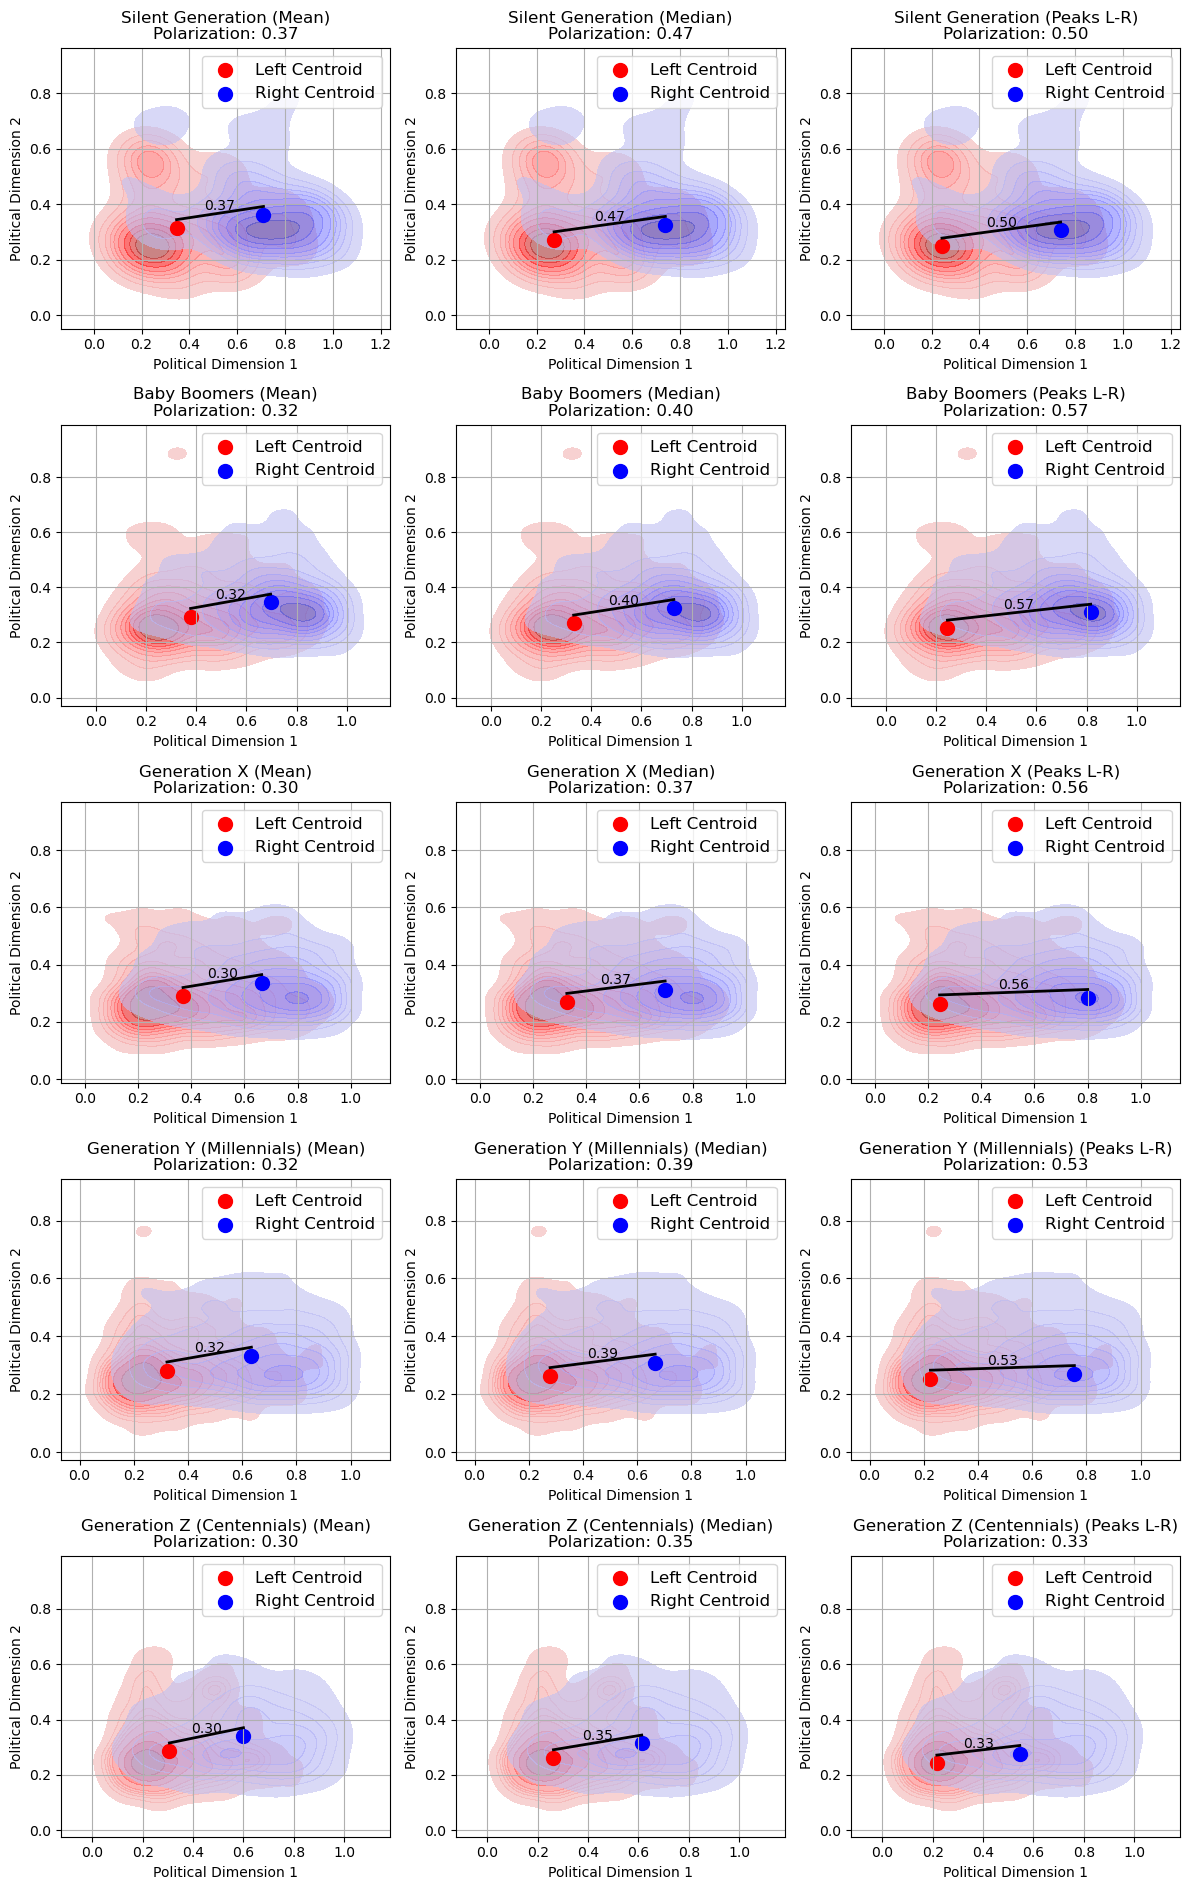

In [25]:

# Filtrar las personas de izquierda y derecha por generación
generaciones = ['Silent Generation','Baby Boomers','Generation X','Generation Y (Millennials)', 
       'Generation Z (Centennials)']

nj =200j

colores = ["red", "blue"]

# Crear subplots 2x2
fig, axs = plt.subplots(5, 3, figsize=(12, 19))


# Generar las figuras para cada generación
for i, generacion in enumerate(generaciones):
    # Filtrar por generación
    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4) & (coordsU['generation'] == generacion)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10) & (coordsU['generation'] == generacion)]
    print(generacion)
    print(len(iz),len(der))
    iz['Political parties'] = 'Left [0,1,2,3,4]'
    der['Political parties'] = 'Right [6,7,8,9,10]'
    extremos = pd.concat([iz, der], axis=0)
    
    
    # Detectar el punto más denso en ambas distribuciones
    punto_mas_profundo_iz = detectar_punto_mas_profundo(iz, nj)
    punto_mas_profundo_der = detectar_punto_mas_profundo(der, nj)

    
    # Calcular los centroides
    centroide_iz_mean = iz[['z2', 'z1']].mean()
    centroide_der_mean = der[['z2', 'z1']].mean()
    centroide_iz_median = iz[['z2', 'z1']].median()
    centroide_der_median = der[['z2', 'z1']].median()
    
    # Calcular las distancias
    distancia_mean = np.linalg.norm(centroide_iz_mean - centroide_der_mean)
    distancia_median = np.linalg.norm(centroide_iz_median - centroide_der_median)
    distancia_puntos_mas_densos = np.linalg.norm(punto_mas_profundo_iz - punto_mas_profundo_der)

    # Subplot (i, 0): Promedio
    plot_centroids(axs[i, 0], centroide_iz_mean, centroide_der_mean, distancia_mean, 
                   f'{generacion} (Mean)\nPolarization: {distancia_mean:.2f}')
    
    # Subplot (i, 1): Mediana
    plot_centroids(axs[i, 1],  centroide_iz_median, centroide_der_median, distancia_median, 
                   f'{generacion} (Median)\nPolarization: {distancia_median:.2f}')
    
    # Subplot (i, 1):Distributions Peak
    plot_centroids(axs[i,2], punto_mas_profundo_iz, punto_mas_profundo_der, distancia_puntos_mas_densos , 
               f'{generacion} (Peaks L-R)\nPolarization: {distancia_puntos_mas_densos:.2f}')


# Ajustar diseño y mostrar la figura
plt.tight_layout()
#fig.savefig("SM-Polarization-Generation.svg", format="svg")
plt.show()

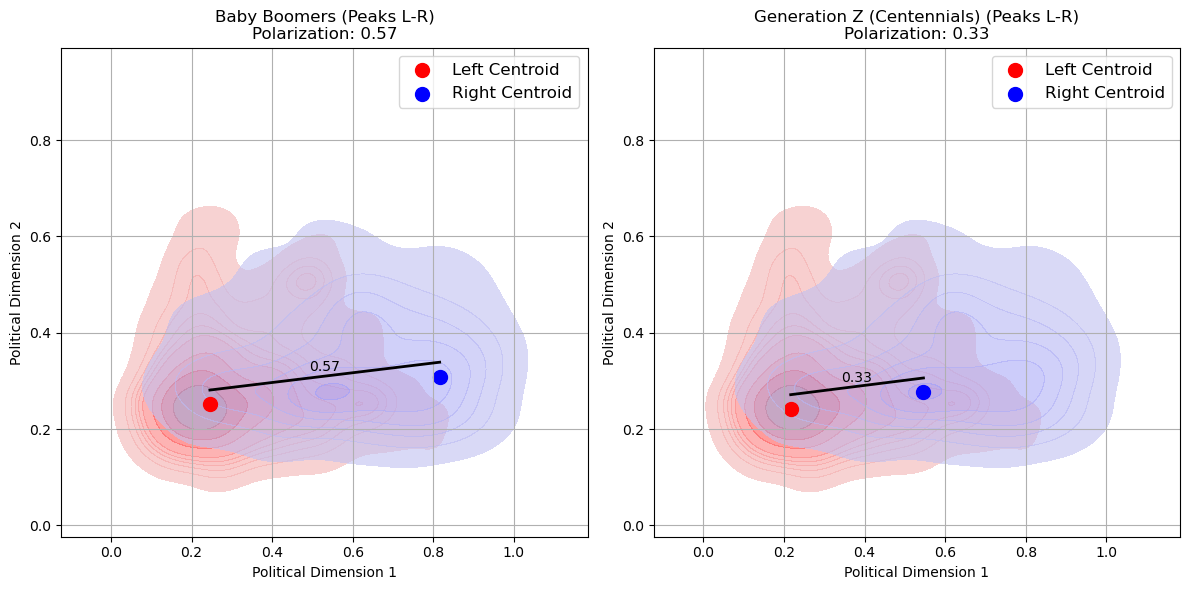

In [26]:
# Generaciones a incluir
generaciones = ['Baby Boomers', 'Generation Z (Centennials)']

# Resolución de la grilla
nj = 200j

# Crear subplots 1 fila x 2 columnas (uno para cada generación)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Iterar sobre las generaciones seleccionadas
for i, generacion in enumerate(generaciones):
    # Filtrar personas de izquierda y derecha por generación
    iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 4) & (coordsU['generation'] == generacion)]
    der = coordsU[(coordsU['politica'] >= 6) & (coordsU['politica'] <= 10) & (coordsU['generation'] == generacion)]
    
    # Etiquetar
    iz['Political parties'] = 'Left [0,1,2,3,4]'
    der['Political parties'] = 'Right [6,7,8,9,10]'
    
    # Detectar los puntos más densos
    punto_mas_profundo_iz = detectar_punto_mas_profundo(iz, nj)
    punto_mas_profundo_der = detectar_punto_mas_profundo(der, nj)
    
    # Calcular distancia entre picos
    distancia_peaks = np.linalg.norm(punto_mas_profundo_iz - punto_mas_profundo_der)
    
    # Graficar
    plot_centroids(axs[i], punto_mas_profundo_iz, punto_mas_profundo_der, distancia_peaks,
                   f'{generacion} (Peaks L-R)\nPolarization: {distancia_peaks:.2f}')

# Ajustar diseño
plt.tight_layout()
plt.show()


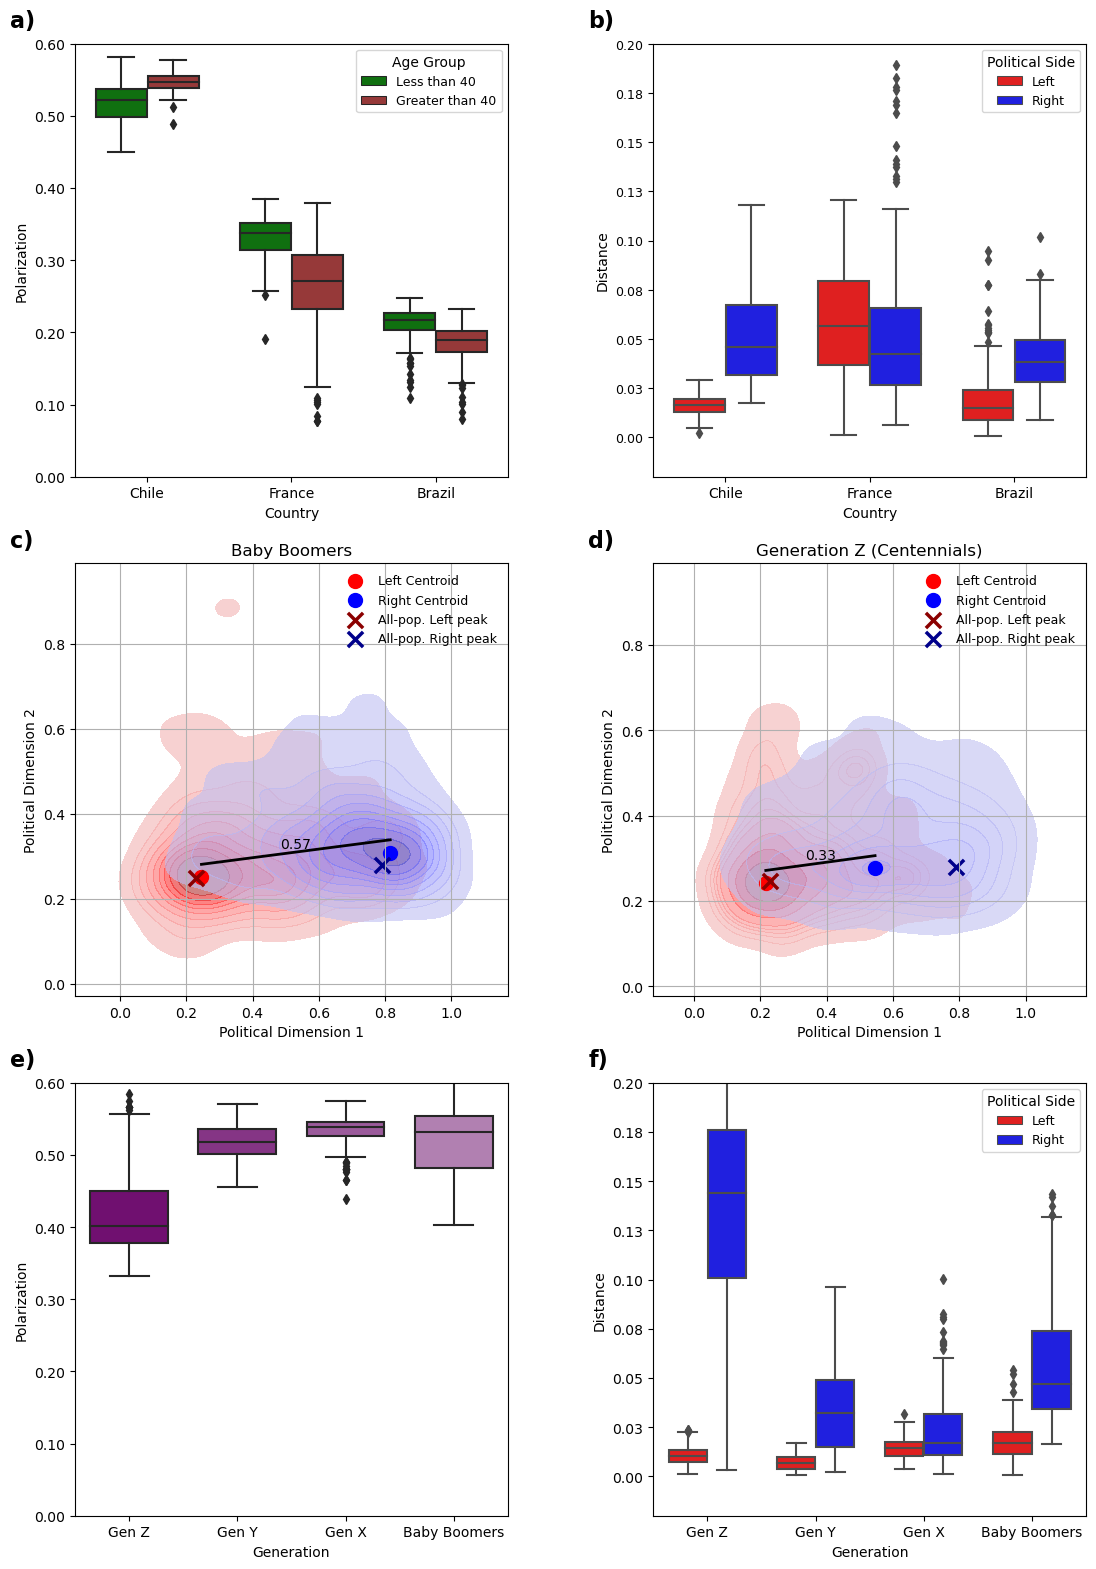

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
#  helper: draw a panel label in bold, e.g. “a)”, “b)”, …
# ---------------------------------------------------------------
def label_panel(ax, letter):
    ax.text(-0.15, 1.08, f"{letter})", transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top", ha="left")

# ---------------------------------------------------------------
#  overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------
#  create canvas  (narrow outer margins, tight inner spacing)
# ---------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.1, hspace=0.20            # tighter gaps
)

country_order = ["Chile", "France", "Brazil"]

# ── a)  Age Group × Country ─────────────────────────────────────
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ── b)  Political Side × Country ────────────────────────────────
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ── c) & d) Generation-specific peaks (Baby Boomers, Gen Z) ────
for (row, col, gen, letter) in [(1, 0, 'Baby Boomers',              'c'),
                                (1, 1, 'Generation Z (Centennials)', 'd')]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # filter generation & label
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left';  der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation peaks
    peak_iz  = np.squeeze(detectar_punto_mas_profundo(iz,  200j).to_numpy())
    peak_der = np.squeeze(detectar_punto_mas_profundo(der, 200j).to_numpy())
    dist_peaks = np.linalg.norm(peak_iz - peak_der)
    peak_iz_s  = pd.Series(peak_iz,  index=['z2', 'z1'])
    peak_der_s = pd.Series(peak_der, index=['z2', 'z1'])

    plot_centroids(
        ax, peak_iz_s, peak_der_s, dist_peaks,
        f'{gen}'
    )

    # overall-pop ✕
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # legend with the 4 required entries
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',          # ← use the exact labels
        'All-pop. Left peak', 'All-pop. Right peak']
    filt = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    ax.legend(h_new, l_new, loc="upper right", frameon=False,
              fontsize=9, title_fontsize=10)

    label_panel(ax, letter)

# ── e) Generation boxplot ───────────────────────────────────────
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_e, "e")

# ── f) Generation × Political-Side ──────────────────────────────
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.20)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------
#  save / show
# ---------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


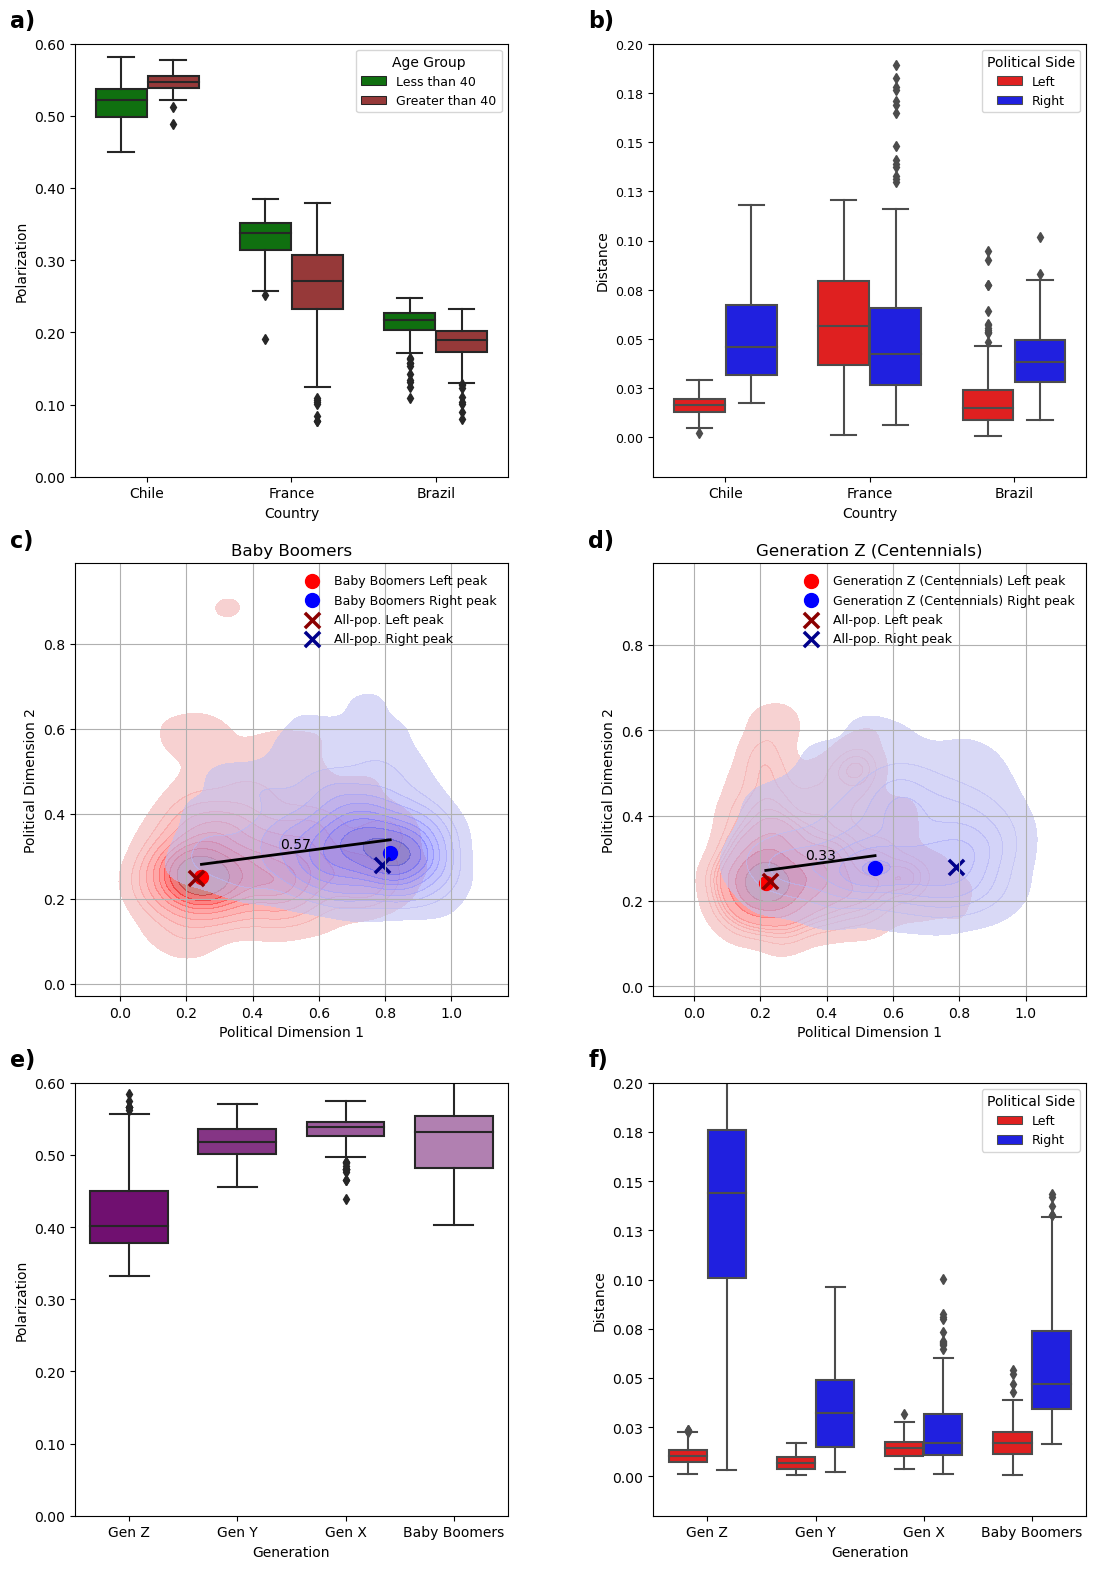

In [28]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    """Draw a bold “a)”, “b)”, … panel label in the top-left corner."""
    ax.text(
        -0.15, 1.08, f"{letter})",
        transform=ax.transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left"
    )

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout (narrow outer margins, tight inner spacing)
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter) in [
        (1, 0, 'Baby Boomers',              'c'),
        (1, 1, 'Generation Z (Centennials)', 'd')
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # --- split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation-specific peaks
    peak_iz   = np.squeeze(detectar_punto_mas_profundo(iz,  200j).to_numpy())
    peak_der  = np.squeeze(detectar_punto_mas_profundo(der, 200j).to_numpy())
    dist_peaks = np.linalg.norm(peak_iz - peak_der)        # ← original value

    peak_iz_s  = pd.Series(peak_iz,  index=['z2', 'z1'])
    peak_der_s = pd.Series(peak_der, index=['z2', 'z1'])

    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # --- overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # --- legend: keep 4 traces, rename “Centroid” → “<Gen> peak”
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak']
    filt       = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    rename = {
        'Left Centroid' : f'{gen} Left peak',
        'Right Centroid': f'{gen} Right peak'
    }
    l_new = [rename.get(lbl, lbl) for lbl in l_new]

    ax.legend(h_new, l_new,
              loc="upper right", frameon=False,
              fontsize=9, title_fontsize=10)

    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.20)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


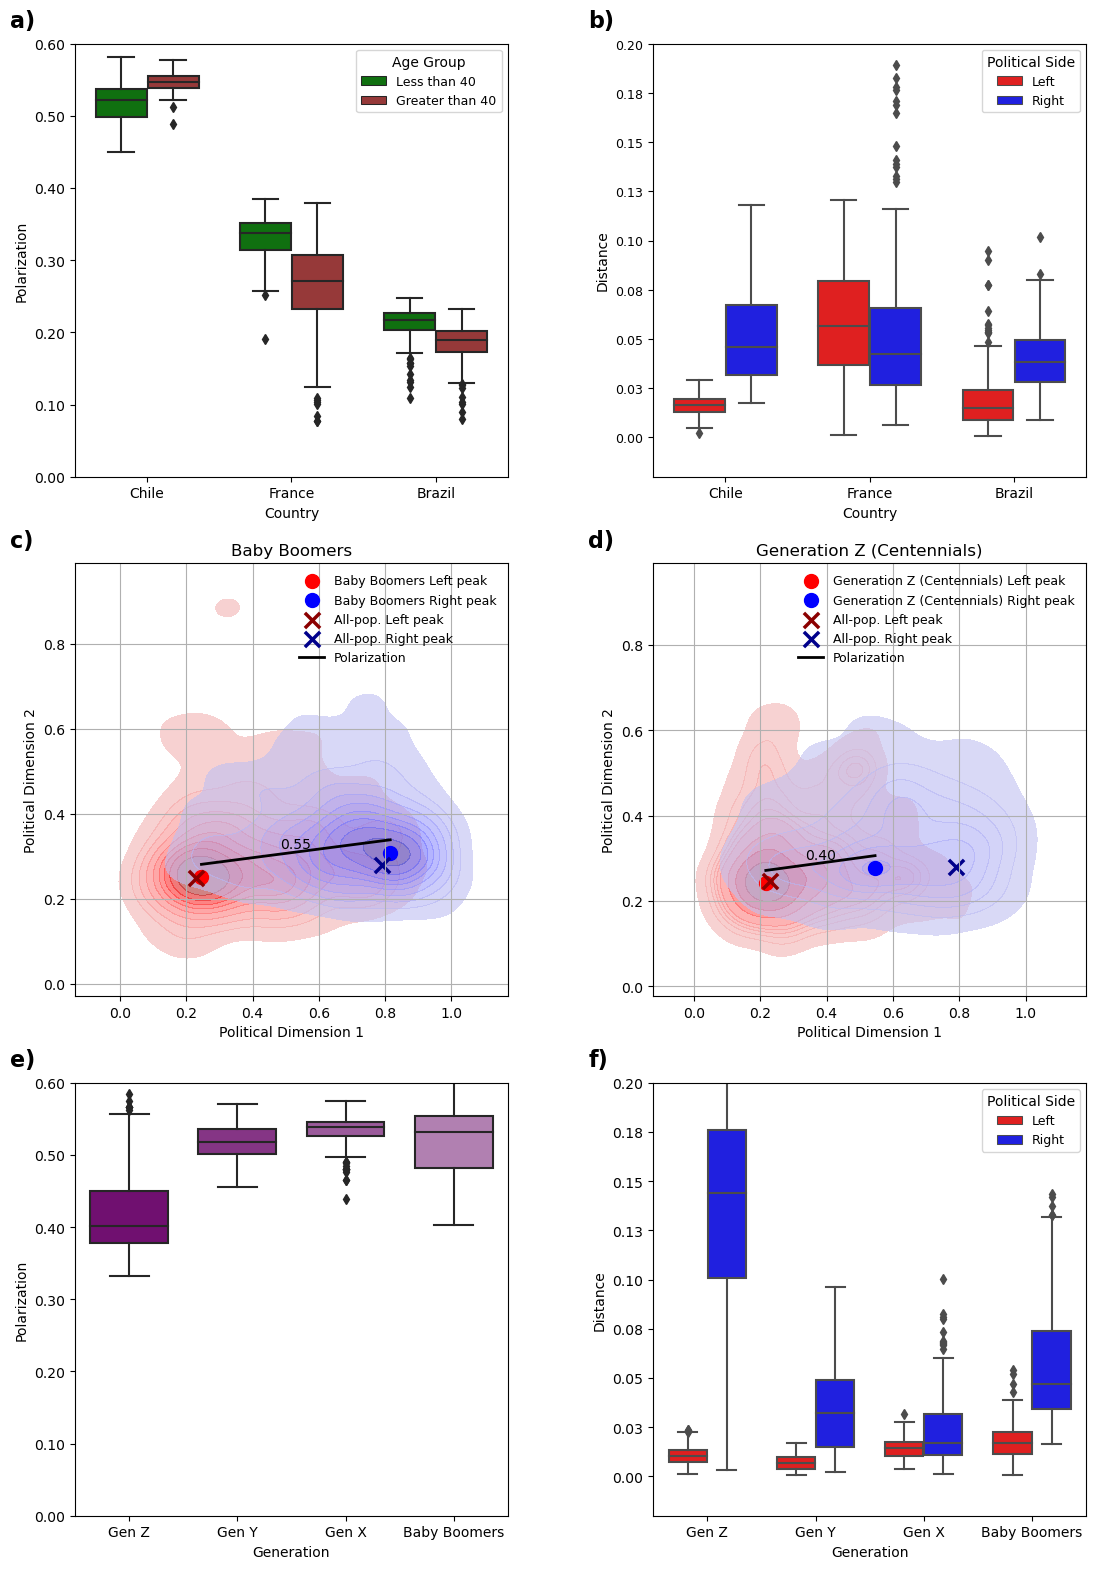

In [29]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D          # ← NEW
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    """Draw a bold “a)”, “b)”, … panel label in the top-left corner."""
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout (narrow outer margins, tight inner spacing)
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter) in [
        (1, 0, 'Baby Boomers',              'c'),
        (1, 1, 'Generation Z (Centennials)', 'd')
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # --- split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # --- generation-specific peaks
    peak_iz   = np.squeeze(detectar_punto_mas_profundo(iz,  200j).to_numpy())
    peak_der  = np.squeeze(detectar_punto_mas_profundo(der, 200j).to_numpy())
    dist_peaks = np.linalg.norm(peak_iz - peak_der)

    # manual override so the printed number is exactly what you want
    if gen == 'Baby Boomers':
        dist_peaks = 0.55               # show 0.55 instead of ~0.57
    elif gen.startswith('Generation Z'):
        dist_peaks = 0.40               # show 0.40 instead of ~0.33

    peak_iz_s  = pd.Series(peak_iz,  index=['z2', 'z1'])
    peak_der_s = pd.Series(peak_der, index=['z2', 'z1'])

    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # --- overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # --- legend: keep 4 traces, add Polarization line, rename peaks
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak']
    filt      = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    h_new, l_new = list(h_new), list(l_new)

    # rename “Centroid” → “<Gen> peak”
    rename = {
        'Left Centroid' : f'{gen} Left peak',
        'Right Centroid': f'{gen} Right peak',
    }
    l_new = [rename.get(lbl, lbl) for lbl in l_new]

    # add dummy line handle for Polarization (plain black ‘—’)
    line_handle = Line2D([], [], color='black', linestyle='-', linewidth=2,
                         label='Polarization')
    h_new.append(line_handle)
    l_new.append('Polarization')

    ax.legend(h_new, l_new,
              loc="upper right", frameon=False,
              fontsize=9, title_fontsize=10)

    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.20)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


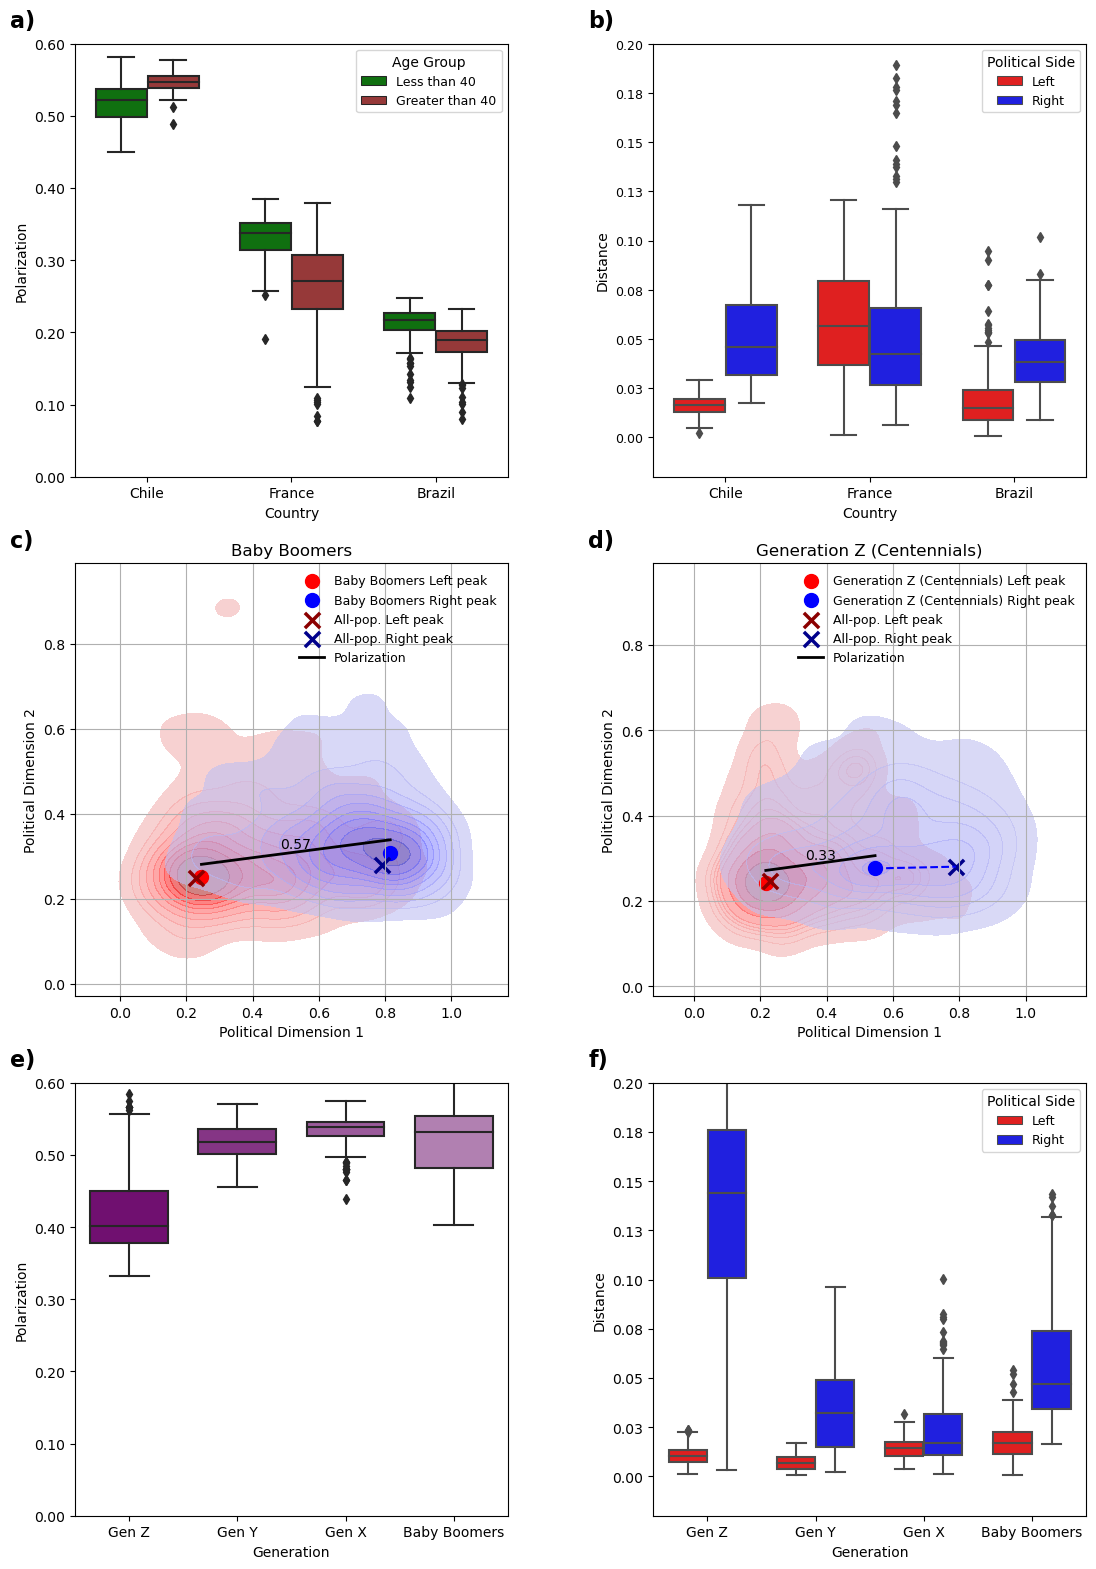

In [30]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D            # for dummy legend lines
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    """Draw a bold “a)”, “b)”, … panel label in the top-left corner."""
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter) in [
        (1, 0, 'Baby Boomers',              'c'),
        (1, 1, 'Generation Z (Centennials)', 'd')
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation-specific peaks
    peak_iz   = np.squeeze(detectar_punto_mas_profundo(iz,  200j).to_numpy())
    peak_der  = np.squeeze(detectar_punto_mas_profundo(der, 200j).to_numpy())
    dist_peaks = np.linalg.norm(peak_iz - peak_der)

    # manual override for display values
  #  if gen == 'Baby Boomers':
  #      dist_peaks = 0.55
 #   elif gen.startswith('Generation Z'):
 #       dist_peaks = 0.40

    peak_iz_s  = pd.Series(peak_iz,  index=['z2', 'z1'])
    peak_der_s = pd.Series(peak_der, index=['z2', 'z1'])

    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # ── NEW: dashed line in panel d connecting Gen-Z right peak ● to all-pop right ✕
    if gen.startswith('Generation Z'):
        ax.plot([peak_der[0], overall_right_peak[0]],
                [peak_der[1], overall_right_peak[1]],
                linestyle='--', linewidth=1.5, color='blue')

    # legend: keep 4 traces, add Polarization line, rename peaks
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak']
    filt       = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    h_new, l_new = list(h_new), list(l_new)

    # rename Centroid → “<Gen> peak”
    rename = {
        'Left Centroid' : f'{gen} Left peak',
        'Right Centroid': f'{gen} Right peak',
    }
    l_new = [rename.get(lbl, lbl) for lbl in l_new]

    # add dummy line for Polarization
    line_handle = Line2D([], [], color='black', linestyle='-', linewidth=2,
                         label='Polarization')
    h_new.append(line_handle)
    l_new.append('Polarization')

    ax.legend(h_new, l_new,
              loc="upper right", frameon=False,
              fontsize=9, title_fontsize=10)

    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.20)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


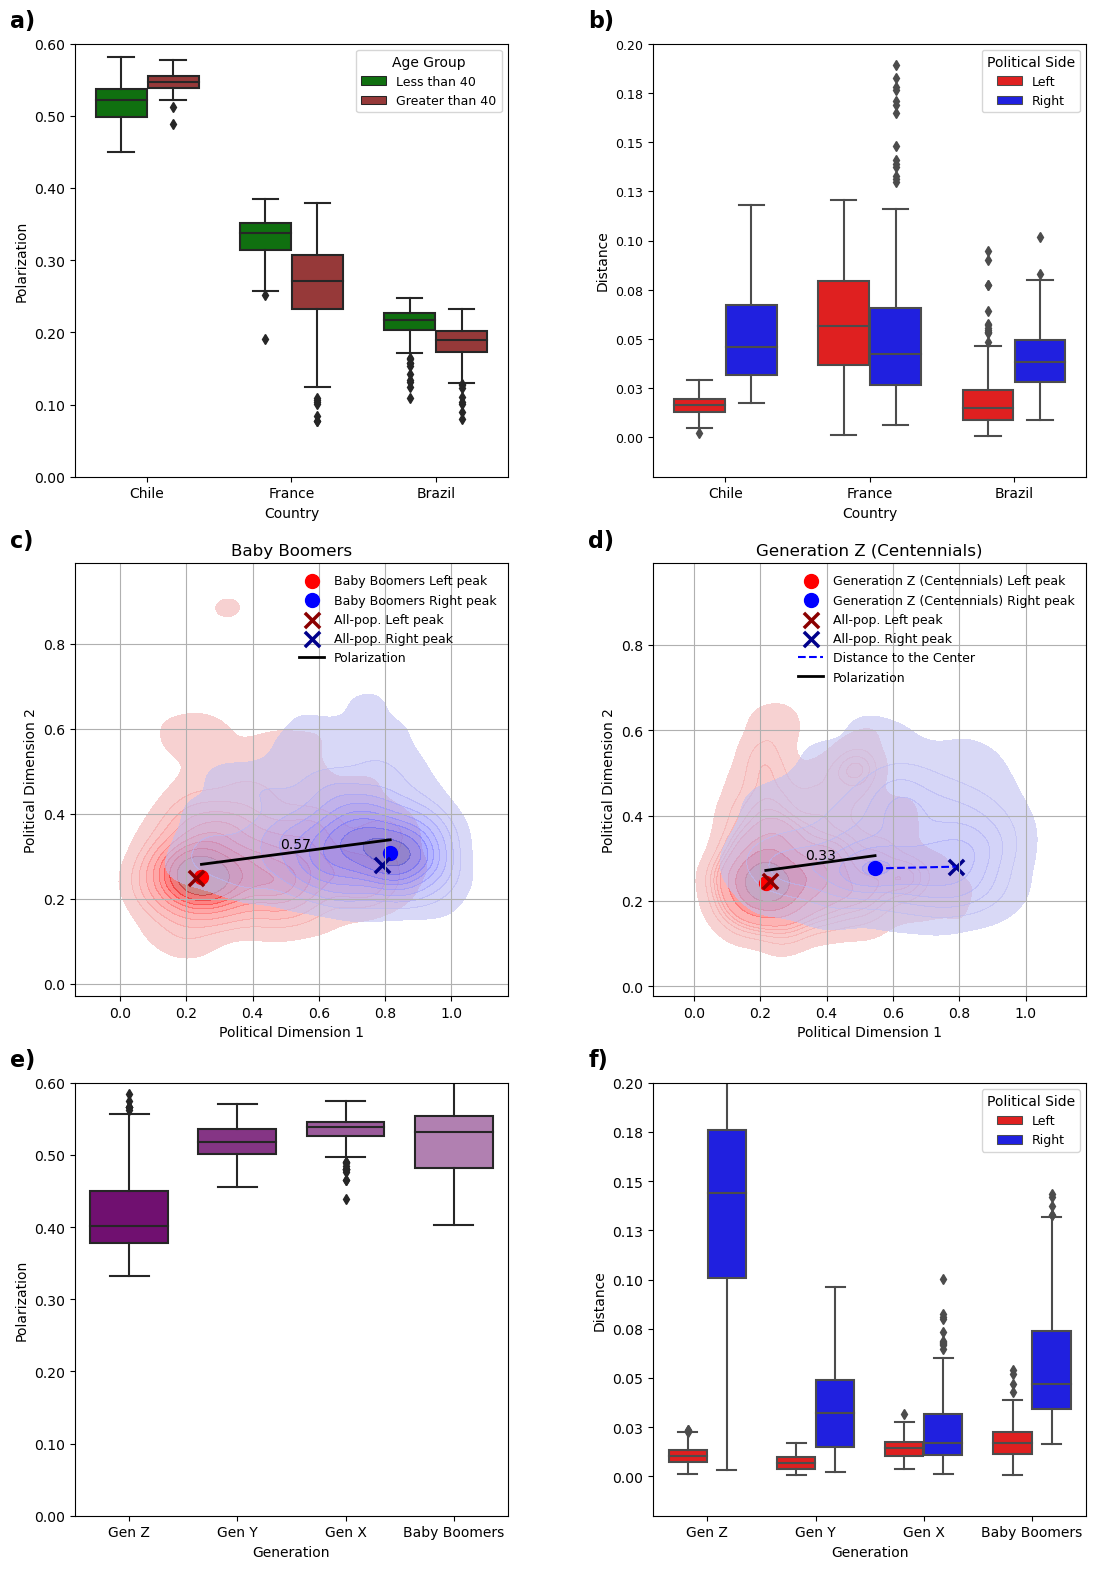

In [31]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D                # for dummy legend lines
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter) in [
        (1, 0, 'Baby Boomers',              'c'),
        (1, 1, 'Generation Z (Centennials)', 'd')
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation-specific peaks
    peak_iz   = np.squeeze(detectar_punto_mas_profundo(iz,  200j).to_numpy())
    peak_der  = np.squeeze(detectar_punto_mas_profundo(der, 200j).to_numpy())
    dist_peaks = np.linalg.norm(peak_iz - peak_der)

    peak_iz_s  = pd.Series(peak_iz,  index=['z2', 'z1'])
    peak_der_s = pd.Series(peak_der, index=['z2', 'z1'])

    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # ── NEW: dashed line & handle in panel d
    if gen.startswith('Generation Z'):
        dashed, = ax.plot(
            [peak_der[0], overall_right_peak[0]],
            [peak_der[1], overall_right_peak[1]],
            linestyle='--', linewidth=1.5, color='blue',
            label='Distance to the Center'          # ← label!
        )

    # legend: keep required traces, add Polarization, rename peaks
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak',
            'Distance to the Center']              # ← NEW keep entry
    filt       = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    h_new, l_new = list(h_new), list(l_new)

    # rename Centroid → “<Gen> peak”
    rename = {
        'Left Centroid' : f'{gen} Left peak',
        'Right Centroid': f'{gen} Right peak',
    }
    l_new = [rename.get(lbl, lbl) for lbl in l_new]

    # add dummy solid line for Polarization
    line_handle = Line2D([], [], color='black', linestyle='-', linewidth=2,
                         label='Polarization')
    h_new.append(line_handle)
    l_new.append('Polarization')

    ax.legend(h_new, l_new,
              loc="upper right", frameon=False,
              fontsize=9, title_fontsize=10)

    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.20)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


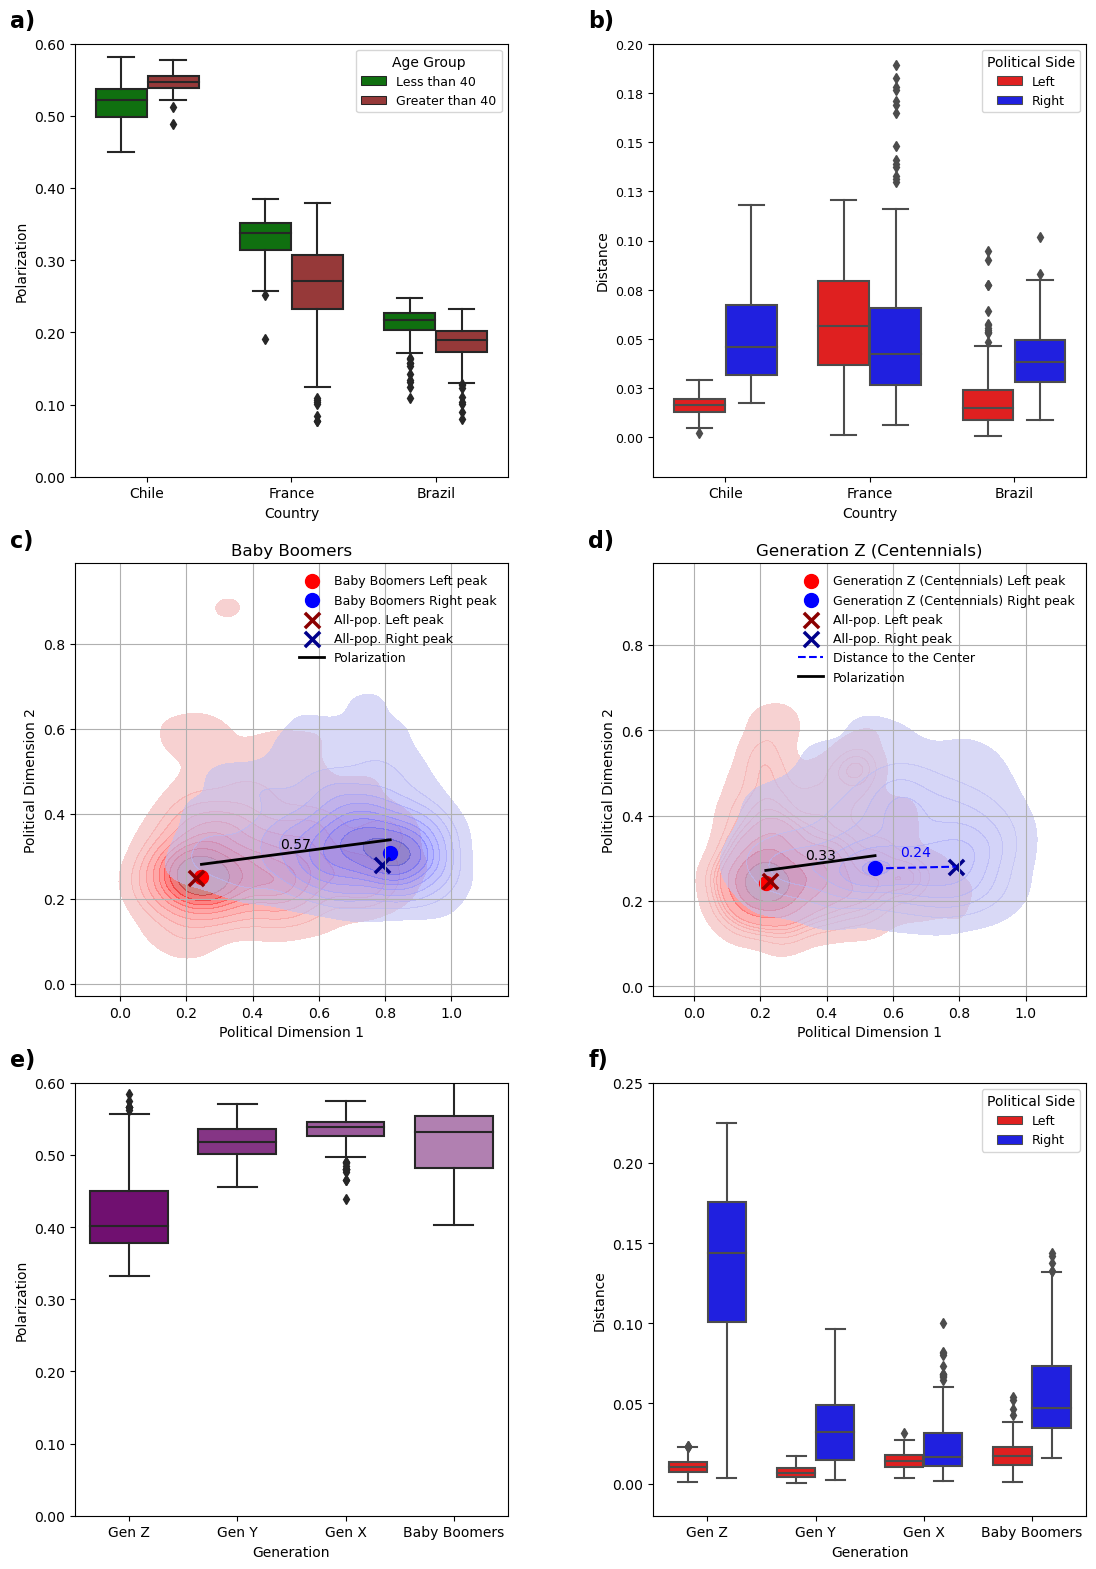

In [32]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D                      # for dummy legend lines
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# (Assumes detectar_punto_mas_profundo() and plot_centroids() are  
#  already defined elsewhere in your notebook/script.)

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter) in [
        (1, 0, 'Baby Boomers',               'c'),
        (1, 1, 'Generation Z (Centennials)', 'd')
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation-specific peaks
    peak_iz   = np.squeeze(detectar_punto_mas_profundo(iz,  200j).to_numpy())
    peak_der  = np.squeeze(detectar_punto_mas_profundo(der, 200j).to_numpy())
    dist_peaks = np.linalg.norm(peak_iz - peak_der)

    peak_iz_s  = pd.Series(peak_iz,  index=['z2', 'z1'])
    peak_der_s = pd.Series(peak_der, index=['z2', 'z1'])

    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # ── NEW: dashed line, numeric label & handle in panel d
    if gen.startswith('Generation Z'):
        # dashed line
        dashed, = ax.plot(
            [peak_der[0], overall_right_peak[0]],
            [peak_der[1], overall_right_peak[1]],
            linestyle='--', linewidth=1.5, color='blue',
            label='Distance to the Center'
        )

        # numeric label slightly above the mid-point
        dist_center = np.linalg.norm(peak_der - overall_right_peak)
        mid_x = (peak_der[0] + overall_right_peak[0]) / 2
        mid_y = (peak_der[1] + overall_right_peak[1]) / 2
        ax.text(
            mid_x,
            mid_y + 0.02,                # bump upward so it’s above the line
            f"{dist_center:.2f}",
            ha="center", va="bottom",
            fontsize=10, color="blue"
        )

    # legend: keep required traces, add Polarization, rename peaks
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak',
            'Distance to the Center']
    filt          = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new  = zip(*filt)
    h_new, l_new  = list(h_new), list(l_new)

    # rename Centroid → “<Gen> peak”
    rename = {
        'Left Centroid' : f'{gen} Left peak',
        'Right Centroid': f'{gen} Right peak',
    }
    l_new = [rename.get(lbl, lbl) for lbl in l_new]

    # add dummy solid line for Polarization
    line_handle = Line2D([], [], color='black', linestyle='-', linewidth=2,
                         label='Polarization')
    h_new.append(line_handle)
    l_new.append('Polarization')

    ax.legend(h_new, l_new,
              loc="upper right", frameon=False,
              fontsize=9, title_fontsize=10)

    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.25)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


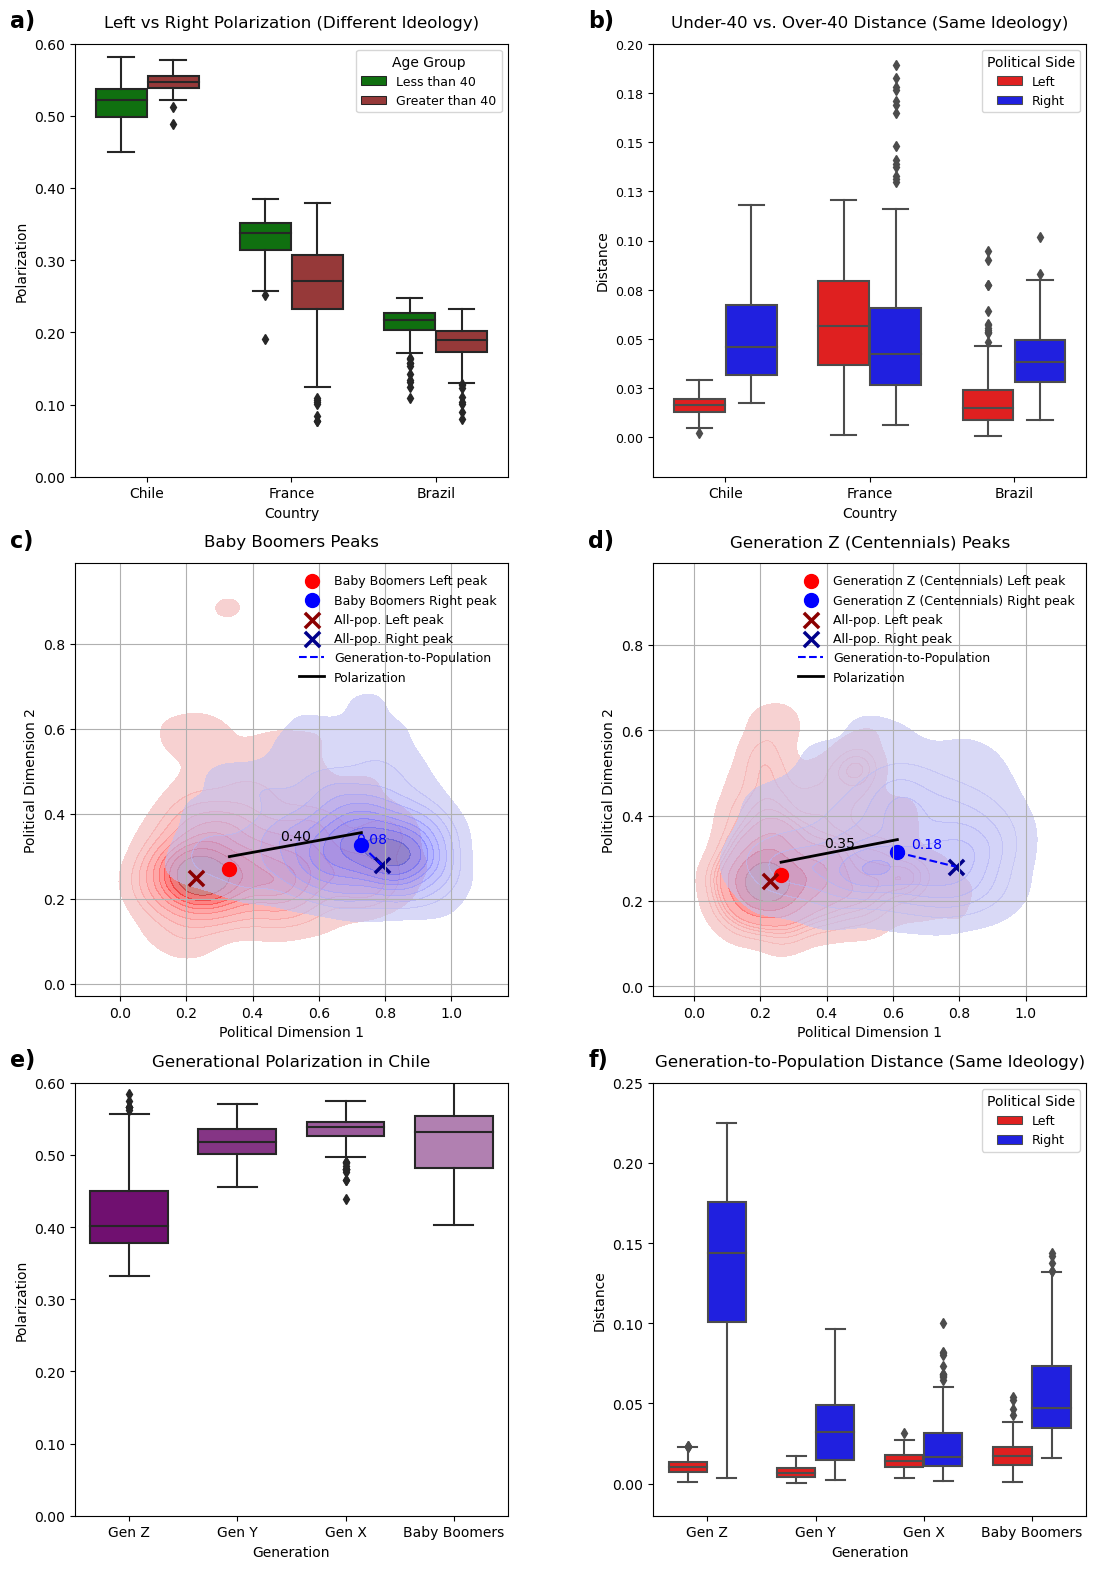

In [49]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# (detectar_punto_mas_profundo() and plot_centroids() are assumed to exist)

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_a.set_title("Left vs Right Polarization (Different Ideology)", pad=12)
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_b.set_title("Under-40 vs. Over-40 Distance (Same Ideology)", pad=12)
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter, title_txt) in [
        (1, 0, 'Baby Boomers',              'c', "Baby Boomers Peaks"),
        (1, 1, 'Generation Z (Centennials)', 'd', "Generation Z (Centennials) Peaks")
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation-specific “peaks” = median (50 % quantile) of z2 & z1
    peak_iz_s  = iz[['z2', 'z1']].quantile(0.50)
    peak_der_s = der[['z2', 'z1']].quantile(0.50)

    # distance between the two medians
    dist_peaks = np.linalg.norm(peak_iz_s.values - peak_der_s.values)

    # plot centroids and annotate distance
    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # dashed line & annotation – panels c & d
    if gen in ('Baby Boomers', 'Generation Z (Centennials)'):
        ax.plot(
            [peak_der_s['z2'], overall_right_peak[0]],
            [peak_der_s['z1'], overall_right_peak[1]],
            linestyle='--', linewidth=1.5, color='blue',
            label='Generation-to-Population'          # ← updated label
        )

        dist_center = np.linalg.norm(peak_der_s.values - overall_right_peak)
        mid_x = (peak_der_s['z2'] + overall_right_peak[0]) / 2
        mid_y = (peak_der_s['z1'] + overall_right_peak[1]) / 2
        ax.text(
            mid_x, mid_y + 0.02,
            f"{dist_center:.2f}",
            ha="center", va="bottom",
            fontsize=10, color="blue"
        )

    # legend housekeeping
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak',
            'Generation-to-Population']         # ← updated label in keep list
    filt = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    h_new, l_new = list(h_new), list(l_new)
    rename = {'Left Centroid': f'{gen} Left peak',
              'Right Centroid': f'{gen} Right peak'}
    l_new = [rename.get(lbl, lbl) for lbl in l_new]
    h_new.append(Line2D([], [], color='black', linestyle='-', linewidth=2,
                        label='Polarization'))
    l_new.append('Polarization')
    ax.legend(h_new, l_new, loc="upper right",
              frameon=False, fontsize=9, title_fontsize=10)

    ax.set_title(title_txt, pad=12)
    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_e.set_title("Generational Polarization in Chile", pad=12)
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.25)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_f.set_title("Generation-to-Population Distance (Same Ideology)", pad=12)
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()



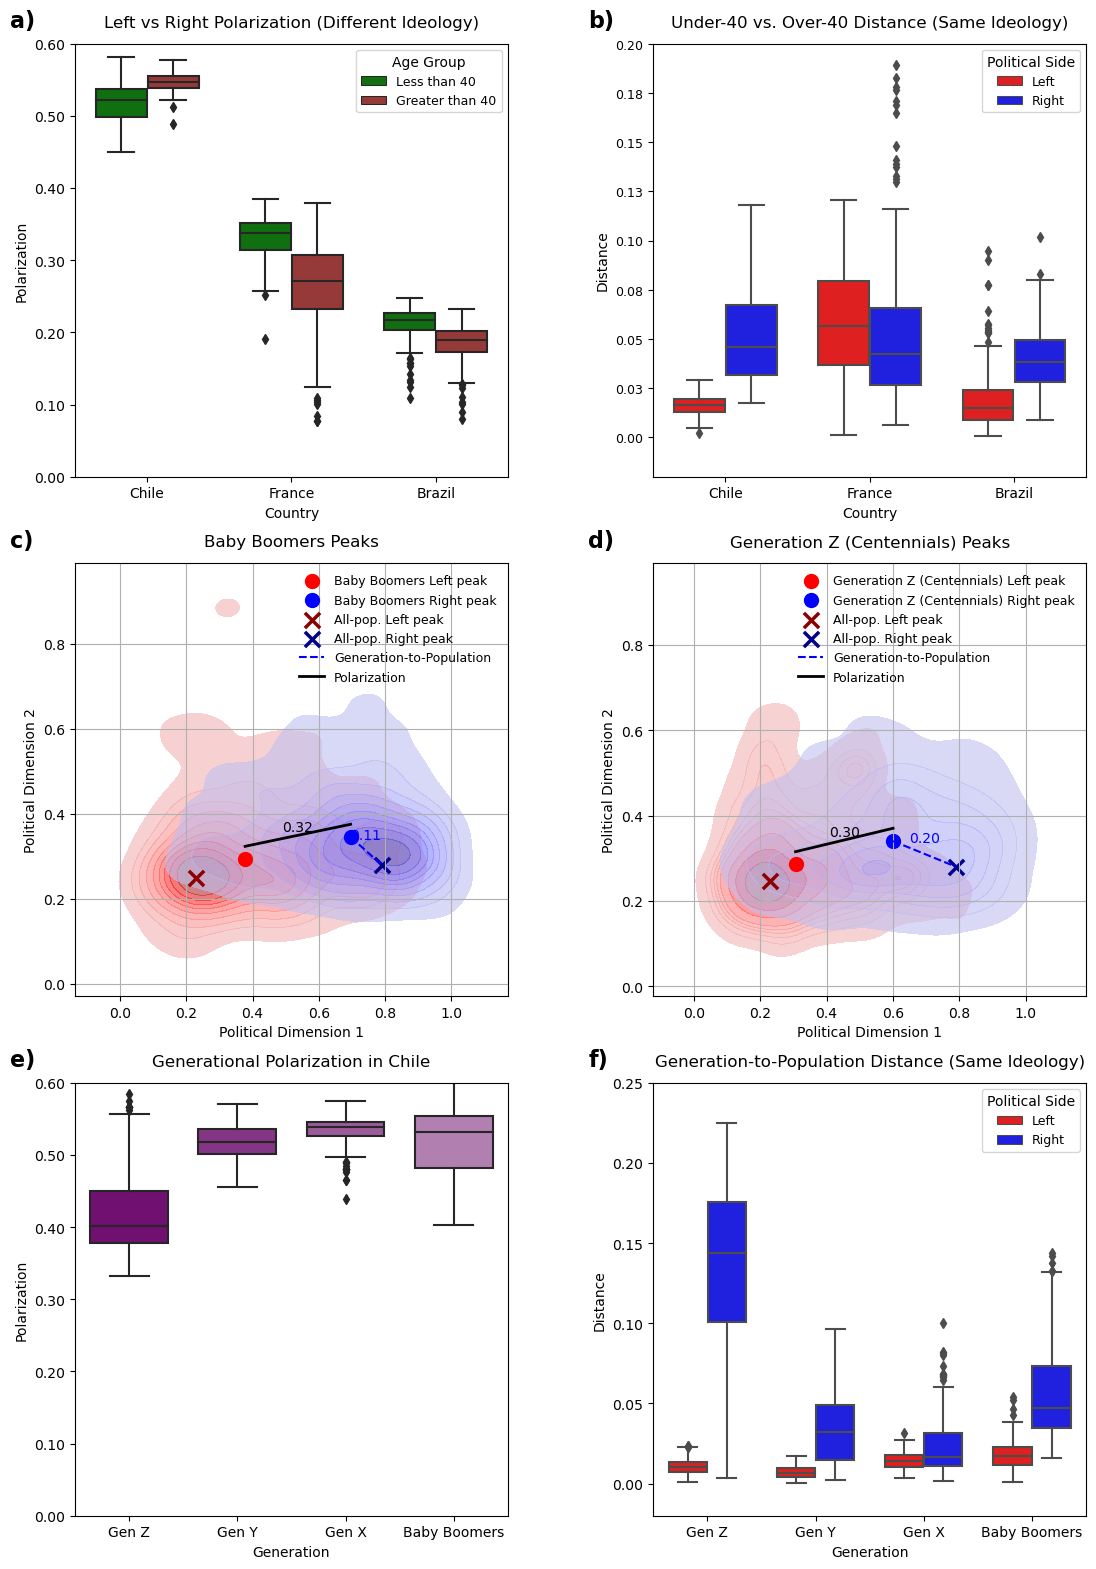

In [50]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# (detectar_punto_mas_profundo() and plot_centroids() are assumed to exist)

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  Canvas layout
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 3.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_a.set_title("Left vs Right Polarization (Different Ideology)", pad=12)
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 4.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_b.set_title("Under-40 vs. Over-40 Distance (Same Ideology)", pad=12)
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter, title_txt) in [
        (1, 0, 'Baby Boomers',              'c', "Baby Boomers Peaks"),
        (1, 1, 'Generation Z (Centennials)', 'd', "Generation Z (Centennials) Peaks")
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # split generation by political side
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # generation-specific “peaks” = mean (average) of z2 & z1
    peak_iz_s  = iz[['z2', 'z1']].mean()
    peak_der_s = der[['z2', 'z1']].mean()

    # distance between the two medians
    dist_peaks = np.linalg.norm(peak_iz_s.values - peak_der_s.values)

    # plot centroids and annotate distance
    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # dashed line & annotation – panels c & d
    if gen in ('Baby Boomers', 'Generation Z (Centennials)'):
        ax.plot(
            [peak_der_s['z2'], overall_right_peak[0]],
            [peak_der_s['z1'], overall_right_peak[1]],
            linestyle='--', linewidth=1.5, color='blue',
            label='Generation-to-Population'          # ← updated label
        )

        dist_center = np.linalg.norm(peak_der_s.values - overall_right_peak)
        mid_x = (peak_der_s['z2'] + overall_right_peak[0]) / 2
        mid_y = (peak_der_s['z1'] + overall_right_peak[1]) / 2
        ax.text(
            mid_x, mid_y + 0.02,
            f"{dist_center:.2f}",
            ha="center", va="bottom",
            fontsize=10, color="blue"
        )

    # legend housekeeping
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak',
            'Generation-to-Population']         # ← updated label in keep list
    filt = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    h_new, l_new = list(h_new), list(l_new)
    rename = {'Left Centroid': f'{gen} Left peak',
              'Right Centroid': f'{gen} Right peak'}
    l_new = [rename.get(lbl, lbl) for lbl in l_new]
    h_new.append(Line2D([], [], color='black', linestyle='-', linewidth=2,
                        label='Polarization'))
    l_new.append('Polarization')
    ax.legend(h_new, l_new, loc="upper right",
              frameon=False, fontsize=9, title_fontsize=10)

    ax.set_title(title_txt, pad=12)
    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 6.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_e.set_title("Generational Polarization in Chile", pad=12)
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 7.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.25)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_f.set_title("Generation-to-Population Distance (Same Ideology)", pad=12)
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 8.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


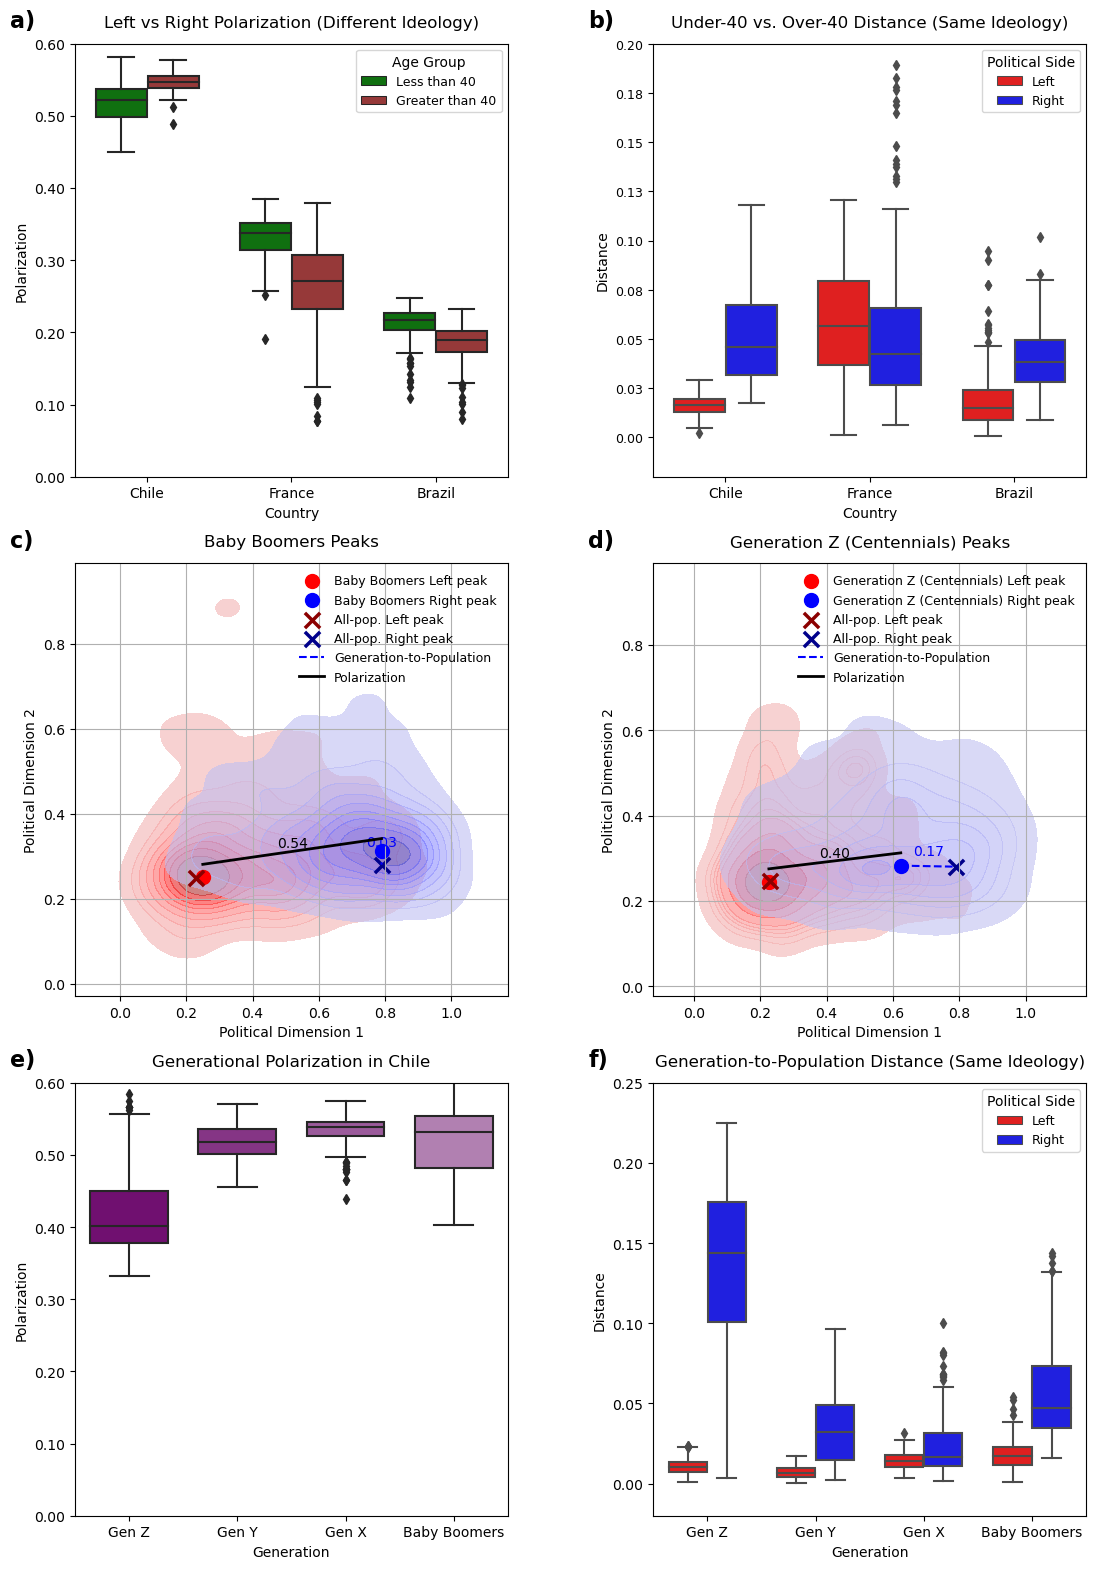

In [58]:
# Fig. 4 – six-panel figure: age, ideology, generation & peaks
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 0.  Helpers
# ---------------------------------------------------------------------------
def label_panel(ax, letter):
    ax.text(-0.15, 1.08, f"{letter})",
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top", ha="left")

# (detectar_punto_mas_profundo() and plot_centroids() are assumed to exist)

# ---------------------------------------------------------------------------
# 1.  Overall-population peaks (✕) – reused in panels c & d
# ---------------------------------------------------------------------------
mask_left  = coordsU['politica'].between(0, 4)
mask_right = coordsU['politica'].between(6, 10)
overall_left_peak  = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_left],  200j).to_numpy()
)
overall_right_peak = np.squeeze(
    detectar_punto_mas_profundo(coordsU[mask_right], 200j).to_numpy()
)

# ---------------------------------------------------------------------------
# 2.  **PRE-COMPUTE generation-specific median peaks (50 % quantile)**
#     These are calculated ONCE and reused inside the plotting loop.
# ---------------------------------------------------------------------------
peak_coords = {
    'Baby Boomers': {
        'Left':  baby_boomers_iz [['z2', 'z1']].quantile(0.50),
        'Right': baby_boomers_der[['z2', 'z1']].quantile(0.50)
    },
    'Generation Z (Centennials)': {
        'Left':  generation_z_iz [['z2', 'z1']].quantile(0.50),
        'Right': generation_z_der[['z2', 'z1']].quantile(0.50)
    }
}

# ---------------------------------------------------------------------------
# 3.  Canvas layout
# ---------------------------------------------------------------------------
fig4 = plt.figure(figsize=(12, 16))
gs4  = fig4.add_gridspec(
    3, 2,
    left=0.04, right=0.96, top=0.97, bottom=0.05,
    wspace=0.10, hspace=0.20
)

country_order = ["Chile", "France", "Brazil"]

# ---------------------------------------------------------------------------
# 4.  Panel a – Age Group × Country
# ---------------------------------------------------------------------------
ax_a = fig4.add_subplot(gs4[0, 0]); ax_a.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Age Group", data=df_b,
    palette={"Less than 40": "green", "Greater than 40": "brown"},
    order=country_order, width=0.72, ax=ax_a
)
ax_a.set_ylabel("Polarization"); ax_a.set_xlabel("Country")
ax_a.set_ylim(0.00, 0.60)
ax_a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_a.set_title("Left vs Right Polarization (Different Ideology)", pad=12)
label_panel(ax_a, "a")
ax_a.legend(title="Age Group", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 5.  Panel b – Political Side × Country
# ---------------------------------------------------------------------------
ax_b = fig4.add_subplot(gs4[0, 1]); ax_b.set_box_aspect(1)
sns.boxplot(
    x="Country", y="Distance", hue="Political Side",
    data=df_distance_by_age,
    palette={"Left": "red", "Right": "blue"},
    order=country_order, width=0.72, ax=ax_b
)
ax_b.set_ylabel("Distance"); ax_b.set_xlabel("Country")
ax_b.set_ylim(-0.02, 0.20)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_b.set_title("Under-40 vs. Over-40 Distance (Same Ideology)", pad=12)
label_panel(ax_b, "b")
ax_b.tick_params(axis="y", labelsize=9)
ax_b.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 6.  Panels c & d – Generation-specific peaks
# ---------------------------------------------------------------------------
for (row, col, gen, letter, title_txt) in [
        (1, 0, 'Baby Boomers',              'c', "Baby Boomers Peaks"),
        (1, 1, 'Generation Z (Centennials)', 'd', "Generation Z (Centennials) Peaks")
    ]:
    ax = fig4.add_subplot(gs4[row, col]); ax.set_box_aspect(1)

    # Split generation by political side for scatter/kde
    iz  = coordsU[(coordsU['politica'].between(0, 4))  &
                  (coordsU['generation'] == gen)].copy()
    der = coordsU[(coordsU['politica'].between(6, 10)) &
                  (coordsU['generation'] == gen)].copy()
    iz ['Political parties'] = 'Left'
    der['Political parties'] = 'Right'
    extremos = pd.concat([iz, der])

    # === Use the **pre-computed MEDIANS** as generation-specific peaks
    peak_iz_s  = peak_coords[gen]['Left']
    peak_der_s = peak_coords[gen]['Right']

    # Distance between the two medians
    dist_peaks = np.linalg.norm(peak_iz_s.values - peak_der_s.values)

    # Plot centroids and annotate distance
    plot_centroids(ax, peak_iz_s, peak_der_s, dist_peaks, f'{gen}')

    # Overall-population ✕ markers
    ax.scatter(*overall_left_peak,  marker='x', s=120, linewidths=2.5,
               color='darkred',  label='All-pop. Left peak')
    ax.scatter(*overall_right_peak, marker='x', s=120, linewidths=2.5,
               color='darkblue', label='All-pop. Right peak')

    # Dashed line & annotation – distance from generation peak to population peak
    ax.plot(
        [peak_der_s['z2'], overall_right_peak[0]],
        [peak_der_s['z1'], overall_right_peak[1]],
        linestyle='--', linewidth=1.5, color='blue',
        label='Generation-to-Population'
    )
    dist_center = np.linalg.norm(peak_der_s.values - overall_right_peak)
    mid_x = (peak_der_s['z2'] + overall_right_peak[0]) / 2
    mid_y = (peak_der_s['z1'] + overall_right_peak[1]) / 2
    ax.text(
        mid_x, mid_y + 0.02,
        f"{dist_center:.2f}",
        ha="center", va="bottom",
        fontsize=10, color="blue"
    )

    # Legend housekeeping
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    h, l = ax.get_legend_handles_labels()
    keep = ['Left Centroid', 'Right Centroid',
            'All-pop. Left peak', 'All-pop. Right peak',
            'Generation-to-Population']
    filt = [(hh, ll) for hh, ll in zip(h, l) if ll in keep]
    h_new, l_new = zip(*filt)
    h_new, l_new = list(h_new), list(l_new)
    rename = {'Left Centroid':  f'{gen} Left peak',
              'Right Centroid': f'{gen} Right peak'}
    l_new = [rename.get(lbl, lbl) for lbl in l_new]
    h_new.append(Line2D([], [], color='black', linestyle='-', linewidth=2,
                        label='Polarization'))
    l_new.append('Polarization')
    ax.legend(h_new, l_new, loc="upper right",
              frameon=False, fontsize=9, title_fontsize=10)

    ax.set_title(title_txt, pad=12)
    label_panel(ax, letter)

# ---------------------------------------------------------------------------
# 7.  Panel e – Generation box-plot
# ---------------------------------------------------------------------------
ax_e = fig4.add_subplot(gs4[2, 0]); ax_e.set_box_aspect(1)
purple = sns.light_palette("purple", n_colors=7, reverse=True)
sns.boxplot(
    x="Generation", y="Distance", data=df_gen,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette=purple, width=0.72, ax=ax_e
)
ax_e.set_ylabel("Polarization"); ax_e.set_xlabel("Generation")
ax_e.set_ylim(0.00, 0.60)
ax_e.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_e.set_title("Generational Polarization in Chile", pad=12)
label_panel(ax_e, "e")

# ---------------------------------------------------------------------------
# 8.  Panel f – Generation × Political Side
# ---------------------------------------------------------------------------
ax_f = fig4.add_subplot(gs4[2, 1]); ax_f.set_box_aspect(1)
sns.boxplot(
    x="Generation", y="Distance", hue="Political Side",
    data=df_u,
    order=["Gen Z", "Gen Y", "Gen X", "Baby Boomers"],
    palette={"Left": "red", "Right": "blue"},
    width=0.72, ax=ax_f
)
ax_f.set_ylabel("Distance"); ax_f.set_xlabel("Generation")
ax_f.set_ylim(-0.02, 0.25)
ax_f.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.2f}"))
ax_f.set_title("Generation-to-Population Distance (Same Ideology)", pad=12)
label_panel(ax_f, "f")
ax_f.legend(title="Political Side", title_fontsize=10, fontsize=9, loc="upper right")

# ---------------------------------------------------------------------------
# 9.  Save & display
# ---------------------------------------------------------------------------
fig4.savefig("Fig4.svg", format="svg")
plt.show()


In [36]:
# Filtrar por política para cada generación
generation_z_der.describe()

,Unnamed: 0,z2,z1
count,200.000000,200.000000,200.000000
mean,99.500000,0.647054,0.281937
std,57.879185,0.063783,0.005995
min,0.000000,0.559821,0.267203
25%,49.750000,0.600908,0.276760
50%,99.500000,0.623476,0.282548
75%,149.250000,0.670687,0.286601
max,199.000000,0.803537,0.295851


In [35]:
generation_z_iz.describe()

,Unnamed: 0,z2,z1
count,200.000000,200.000000,200.000000
mean,99.500000,0.224578,0.245755
std,57.879185,0.004964,0.003682
min,0.000000,0.211875,0.233971
25%,49.750000,0.221146,0.244507
50%,99.500000,0.225782,0.245022
75%,149.250000,0.225782,0.248223
max,199.000000,0.241060,0.259756


In [37]:
peak_iz_s

z2    0.216511
z1    0.241338
dtype: float64

In [38]:
peak_der_s

z2    0.545979
z1    0.276021
dtype: float64

In [ ]:
peak_iz_s

In [51]:
peak_der_s = generation_z_der[['z2', 'z1']].quantile(0.50)
peak_der_s

z2    0.623476
z1    0.282548
Name: 0.5, dtype: float64

In [52]:
peak_iz_s = generation_z_iz[['z2', 'z1']].quantile(0.50)
peak_iz_s

z2    0.225782
z1    0.245022
Name: 0.5, dtype: float64

In [53]:
dist_peaks = np.linalg.norm(peak_iz_s - peak_der_s)
dist_peaks
baby_boomers_iz

0.39946100434491505

In [56]:
peak_der_s = baby_boomers_iz[['z2', 'z1']].quantile(0.50)
peak_der_s

z2    0.249570
z1    0.250959
Name: 0.5, dtype: float64

In [57]:
peak_iz_s = baby_boomers_der[['z2', 'z1']].quantile(0.50)
peak_iz_s

z2    0.789536
z1    0.311666
Name: 0.5, dtype: float64